## Вводные по кейсу

Выполнил: Камалов Тимур

Дата: 02-07-2026

# Описание данных

## Таблица `Users`

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `user_id`         | Уникальный идентификатор пользователя.         |
| `registration_date` | Дата регистрации пользователя.                |
| `age`             | Возраст пользователя.                          |
| `gender`          | Пол.                                |
| `region`          | Регион.                                        |
| `acq_channel`     | Канал привлечения.                             |
| `buyer_segment`   | Сегмент покупателя.                            |
| `cohort_week`     | Неделя привлечения.|
| `cohort_month`    | Месяц привлечения. |

---

## Таблица `Events`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `event_id`    | Уникальный идентификатор события.                                        |
| `user_id`     | Идентификатор пользователя.                                              |
| `event_date`  | Дата события.                                                            |
| `event_type`  | Тип события.   |
| `os`          | Операционная система.               |
| `device`      | Тип устройства.                                |
| `product_name`| Наименование товара, к которому относится событие (если применимо).      |
| `event_week`  | Неделя события.                                          |
| `event_month` | Месяц события .                                           |

---

## Таблица `Orders`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `order_id`    | Уникальный идентификатор заказа.                                         |
| `user_id`     | Идентификатор пользователя, который сделал заказ |
| `order_date`  | Дата и время оформления заказа.                                          |
| `product_name`| Наименование товара.                                                     |
| `quantity`    | Количество единиц товара в заказе.                                       |
| `unit_price`  | Цена за одну единицу товара.                                             |
| `total_price` | Итоговая сумма заказа.                                                   |
| `category_name` | Наименование категории товара.                                         |
| `order_week`  | Неделя заказа.                                           |
| `order_month` | Месяц заказа.                                            |


## Таблица `Campaign_costs`

| Поле         | Описание                                                                 |
|--------------|--------------------------------------------------------------------------|
| `acq_channel`| Канал привлечения.  |
| `spend_month`| Месяц, в который был потрачен бюджет (отражает период, в котором были привлечены пользователи)                      |
| `budget`     | Маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце.                           |



## Описание событий

| Событие             | Описание                                                                                  |
|---------------------|-------------------------------------------------------------------------------------------|
| `page_view`         | Открытие любой страницы сайта или приложения пользователем.                                |
| `product_view`      | Просмотр страницы конкретного товара.                                                     |
| `product_click`     | Клик по товару (например, из списка товаров или на баннере).                              |
| `add_to_cart`       | Добавление товара в корзину.                                                              |
| `remove_from_cart`  | Удаление товара из корзины.                                                               |
| `search`            | Выполнение поиска по сайту или приложению.                                                |
| `filter_apply`      | Применение фильтра (например, по цене, бренду, категории).                                |
| `checkout_start`    | Начало оформления заказа (переход к оформлению корзины).                                  |
| `checkout_complete` | Завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).                                          |
| `user_login`        | Вход пользователя в личный кабинет или аккаунт.                                           |
| `user_logout`       | Выход пользователя из аккаунта.                                                           |
| `wishlist_add`      | Добавление товара в список желаемого (wishlist).                                          |
| `category_view`     | Просмотр страницы категории товаров.                                                      |
| `banner_click`      | Клик по рекламному баннеру на сайте или в приложении.                                     |
| `promo_view`        | Просмотр промо-акции или специального предложения.                                        |


## Выручка маркетплейса = 5% от total_price

# Блок кода и расчета метрик

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [124]:
pa_marketplace_orders = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders.csv', parse_dates=['order_date','order_week','order_month'])
pa_marketplace_campaign_costs = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_campaign_costs.csv', parse_dates=['spend_month'])
pa_marketplace_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users.csv',parse_dates=['registration_date','cohort_week','cohort_month'])
pa_marketplace_events = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events.csv',parse_dates=['event_date','event_week','event_month'])

In [125]:
pa_marketplace_campaign_costs = pa_marketplace_campaign_costs.drop(columns='Unnamed: 0')
display(pa_marketplace_orders.head())
display(pa_marketplace_campaign_costs.head())
display(pa_marketplace_users.head())
display(pa_marketplace_events.head())

display(pa_marketplace_orders.info())
display(pa_marketplace_campaign_costs.info())
display(pa_marketplace_users.info())
display(pa_marketplace_events.info())

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


,acq_channel,spend_month,budget
0,Affiliate,2024-01-01,179343.3875
1,Affiliate,2024-02-01,175488.4875
2,Affiliate,2024-03-01,164543.4750
3,Affiliate,2024-04-01,186869.9750
4,Affiliate,2024-05-01,166443.7750


,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01


,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  datetime64[ns]
 9   order_month    31357 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.4+ MB


...

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 3.0+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      785859 non-null  int64         
 1   user_id       785859 non-null  int64         
 2   event_date    785859 non-null  datetime64[ns]
 3   event_type    785859 non-null  object        
 4   os            785859 non-null  object        
 5   device        785859 non-null  object        
 6   product_name  385740 non-null  object        
 7   event_week    785859 non-null  datetime64[ns]
 8   event_month   785859 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 54.0+ MB


None

In [126]:
print('Число явных дубликатов:')
print(pa_marketplace_orders.duplicated().sum())
print(pa_marketplace_campaign_costs.duplicated().sum())
print(pa_marketplace_users.duplicated().sum())
print(pa_marketplace_events.duplicated().sum())

Число явных дубликатов:
0
0
0
0


In [127]:
for name, df in [('users', pa_marketplace_users),
                 ('events', pa_marketplace_events),
                 ('orders', pa_marketplace_orders),
                 ('costs', pa_marketplace_campaign_costs)]:
    print(f'Таблица: {name}')
    print(f'Строк: {len(df):,}')
    print(f'Столбцы: {list(df.columns)}')
    print()

Таблица: users
Строк: 44,151
Столбцы: ['user_id', 'registration_date', 'age', 'gender', 'region', 'acq_channel', 'buyer_segment', 'cohort_week', 'cohort_month']

Таблица: events
Строк: 785,859
Столбцы: ['event_id', 'user_id', 'event_date', 'event_type', 'os', 'device', 'product_name', 'event_week', 'event_month']

Таблица: orders
Строк: 31,357
Столбцы: ['order_id', 'user_id', 'order_date', 'product_name', 'quantity', 'unit_price', 'total_price', 'category_name', 'order_week', 'order_month']

Таблица: costs
Строк: 88
Столбцы: ['acq_channel', 'spend_month', 'budget']



In [128]:
# Смотрим пероиды данных
print('Регистрации:', pa_marketplace_users['registration_date'].min(), '—', pa_marketplace_users['registration_date'].max())
print('События:', pa_marketplace_events['event_date'].min(), '—', pa_marketplace_events['event_date'].max())
print('Заказы:', pa_marketplace_orders['order_date'].min(), '—', pa_marketplace_orders['order_date'].max())
print('Расходы:', pa_marketplace_campaign_costs['spend_month'].min(), '—', pa_marketplace_campaign_costs['spend_month'].max())

Регистрации: 2024-01-01 00:07:00 — 2024-12-31 23:44:00
События: 2024-01-01 00:00:00 — 2024-12-31 00:00:00
Заказы: 2024-01-01 08:03:45 — 2024-12-31 23:00:53
Расходы: 2024-01-01 00:00:00 — 2025-01-01 00:00:00


In [129]:
print(f'Уникальных пользователей: {pa_marketplace_users["user_id"].nunique()}')
print(f'Уникальных пользователей в events: {pa_marketplace_events["user_id"].nunique()}')
print(f'Уникальных типов событий: {pa_marketplace_events["event_type"].nunique()}')
print(pa_marketplace_events["event_type"].unique())

Уникальных пользователей: 44151
Уникальных пользователей в events: 22138
Уникальных типов событий: 15
['page_view' 'product_view' 'product_click' 'add_to_cart' 'checkout_start'
 'checkout_complete' 'user_logout' 'search' 'category_view' 'filter_apply'
 'promo_view' 'wishlist_add' 'user_login' 'banner_click'
 'remove_from_cart']


Для начала было проведено ознакомление с данными для последующего анализа, опишем основые моменты:
- Таблица: `users` Строк: 44,151; Таблица: `events` Строк: 785,859; Таблица: `orders` Строк: 31,357 Таблица: `costs` Строк: 88
- При считывании датасетов столбцы с датой были приведены к типу `datetime64`;
- Явных дубликатов во всех таблицах не обнаружено
- Пропуски в `product_name` в таблице event связаны с тем, что не все записи отражают взаимодействие с товарами и в таких строках допустимо использование `Nan`;
- Уникальных событий всего 15: `page_view`, `product_view`, `product_click`, `add_to_cart`, `checkout_start`, `checkout_complete`, `user_logout`, `search`,`category_view`, `filter_apply`, `promo_view`, `wishlist_add`, `user_login`,`banner_click`, `remove_from_cart`.
- Все данные представлены в период с 1 января 2024 года по 31 декабря 2024 года включительно.

### 2. Построить обзор ключевых метрик

Для начала подготовим данные, соединим все ключевые метрики в одну таблицу для постоения будущих визуализаций и расчета более сложных метрик

In [130]:
orders = pa_marketplace_orders.copy()
events = pa_marketplace_events.copy()
users = pa_marketplace_users.copy()
costs = pa_marketplace_campaign_costs.copy()

orders['revenue'] = orders['total_price'] * 0.05

orders_agg = (
    orders
    .groupby(['order_id', 'order_month', 'user_id'], as_index=False)
    .agg({'total_price': 'sum', 'revenue': 'sum'})
)

monthly_revenue = orders_agg.groupby('order_month')['revenue'].sum().reset_index(name='revenue')
monthly_active_users = events.groupby('event_month')['user_id'].nunique().reset_index(name='active_users')
monthly_paying_users = orders_agg.groupby('order_month')['user_id'].nunique().reset_index(name='paying_users')
monthly_new_users = users.groupby('cohort_month')['user_id'].nunique().reset_index(name='new_users')
monthly_aov = orders_agg.groupby('order_month')['total_price'].mean().reset_index(name='AOV')
monthly_costs = costs.groupby('spend_month')['budget'].sum().reset_index(name='marketing_cost')

dau = events.groupby('event_date')['user_id'].nunique().reset_index(name='DAU')
wau = events.groupby('event_week')['user_id'].nunique().reset_index(name='WAU')

metrics = (
    monthly_revenue
    .merge(monthly_active_users, left_on='order_month', right_on='event_month', how='left')
    .merge(monthly_paying_users, on='order_month', how='left')
    .merge(monthly_new_users, left_on='order_month', right_on='cohort_month', how='left')
    .merge(monthly_costs, left_on='order_month', right_on='spend_month', how='left')
    .merge(monthly_aov, on='order_month', how='left')
)

metrics = metrics.rename(columns={'order_month': 'month'})

metrics['ARPU'] = metrics['revenue'] / metrics['active_users']
metrics['ARPPU'] = metrics['revenue'] / metrics['paying_users']
metrics['CR'] = metrics['paying_users'] / metrics['active_users']
metrics['CAC'] = metrics['marketing_cost'] / metrics['new_users']
metrics['ROI'] = (metrics['revenue'] - metrics['marketing_cost']) / metrics['marketing_cost']
# metrics['Payback_months'] = metrics['CAC'] / metrics['ARPU']

metrics = metrics[[
    'month', 'revenue', 'marketing_cost',
    'active_users', 'paying_users', 'new_users',
    'AOV', 'ARPU', 'ARPPU', 'CR', 'CAC', 'ROI'
]]

print(metrics.round(2))

        month     revenue  marketing_cost  active_users  paying_users  \
0  2024-01-01   648890.03      1177456.97          1149           454   
1  2024-02-01  1296557.01      1061385.93          2162           839   
2  2024-03-01  1940749.79      1167680.37          2844          1165   
3  2024-04-01  2142838.39      1147739.92          3059          1324   
4  2024-05-01  2478758.10      1225322.28          3310          1404   
5  2024-06-01  2106011.86      1130439.77          3174          1230   
6  2024-07-01  2446535.45      1776446.60          3481          1385   
7  2024-08-01  2465802.40      1811677.75          3861          1385   
8  2024-09-01  1935366.70      1820718.83          3744          1163   
9  2024-10-01  1716108.26      1810802.57          3581           999   
10 2024-11-01  1477100.36      1773970.36          3462           847   
11 2024-12-01  1342492.41      1858569.86          3336           803   

    new_users       AOV    ARPU    ARPPU    CR    

In [131]:
retention_data = events.merge(users[['user_id', 'cohort_month']], on='user_id')
retention_data['lifetime_month'] = (
    (retention_data['event_month'].dt.year - retention_data['cohort_month'].dt.year) * 12 +
    (retention_data['event_month'].dt.month - retention_data['cohort_month'].dt.month)
)
retention_data['cohort_month_str'] = retention_data['cohort_month'].dt.strftime('%Y-%m')

df_pivot_active = retention_data.pivot_table(
    index='cohort_month_str',
    columns='lifetime_month',
    values='user_id',
    aggfunc='nunique'
)

cohort_sizes = users.groupby('cohort_month')['user_id'].nunique().reset_index()
cohort_sizes['cohort_month_str'] = cohort_sizes['cohort_month'].dt.strftime('%Y-%m')
cohort_sizes = cohort_sizes.set_index('cohort_month_str')['user_id']

retention_pct = (df_pivot_active.div(cohort_sizes, axis=0) * 100).round(1)

views = events[events['event_type'] == 'product_view'].groupby('event_month').size().reset_index(name='views')
clicks = events[events['event_type'] == 'product_click'].groupby('event_month').size().reset_index(name='clicks')
ctr_df = views.merge(clicks, on='event_month', how='left')
ctr_df['CTR_%'] = (ctr_df['clicks'] / ctr_df['views'] * 100).round(2)
print(ctr_df)

   event_month  views  clicks  CTR_%
0   2024-01-01   3929    3806  96.87
1   2024-02-01   7667    7474  97.48
2   2024-03-01  10513   10244  97.44
3   2024-04-01  11727   11464  97.76
4   2024-05-01  12468   12219  98.00
5   2024-06-01  11564   11329  97.97
6   2024-07-01  12532   12249  97.74
7   2024-08-01  13214   12896  97.59
8   2024-09-01  12118   11764  97.08
9   2024-10-01  10511   10199  97.03
10  2024-11-01   9778    9415  96.29
11  2024-12-01   9297    8887  95.59


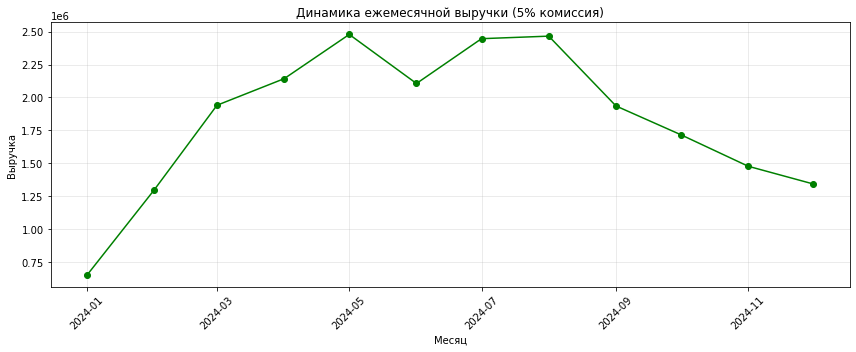

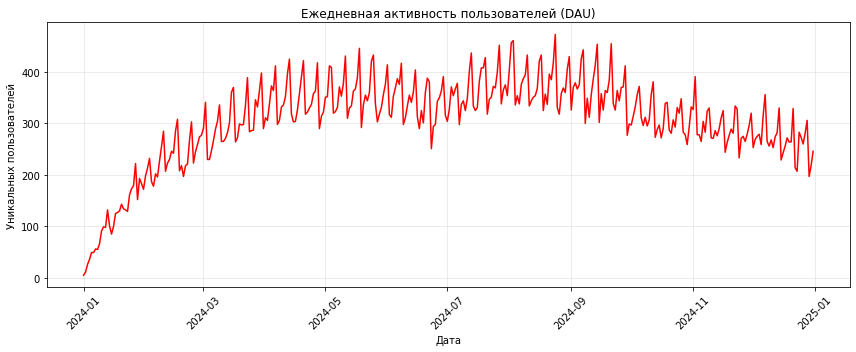

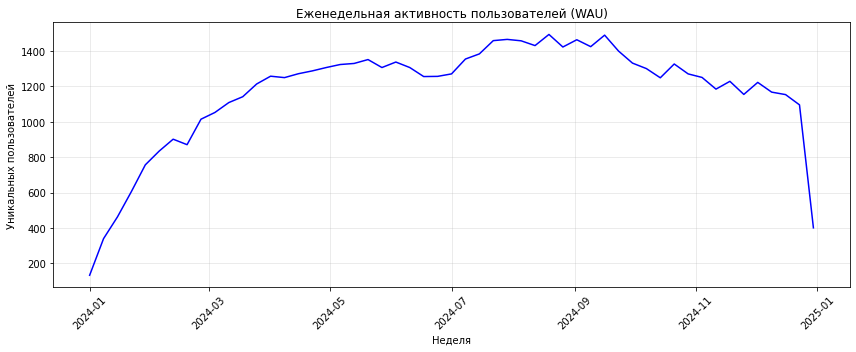

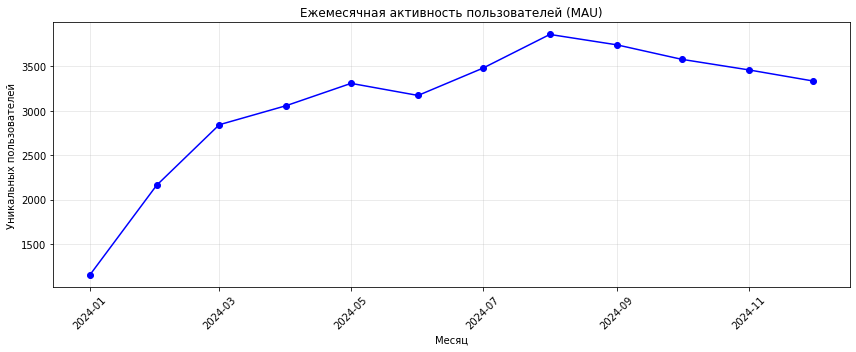

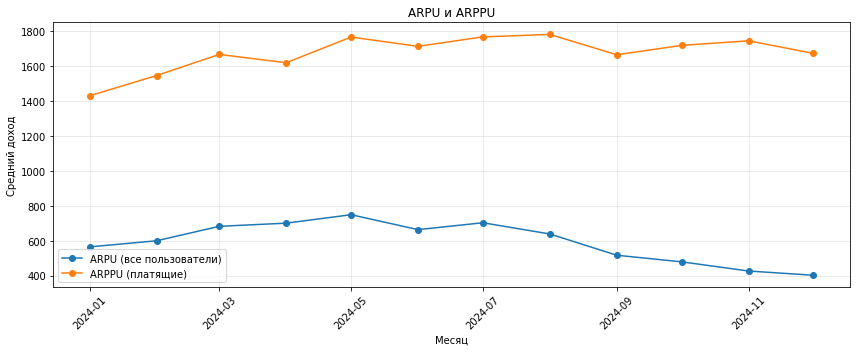

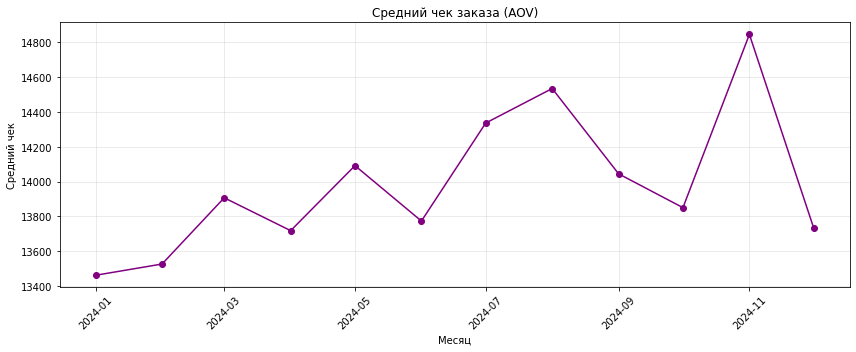

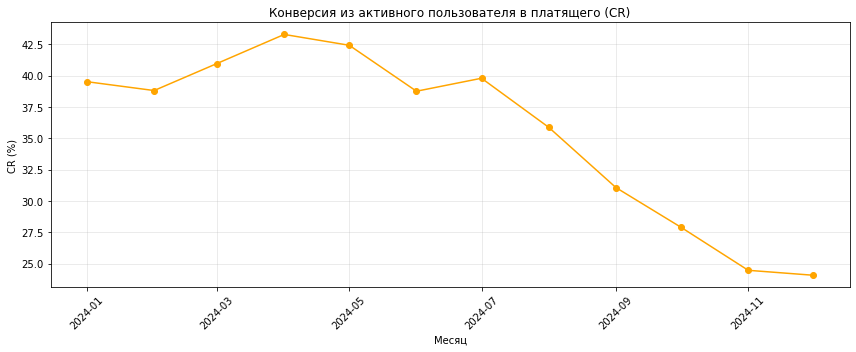

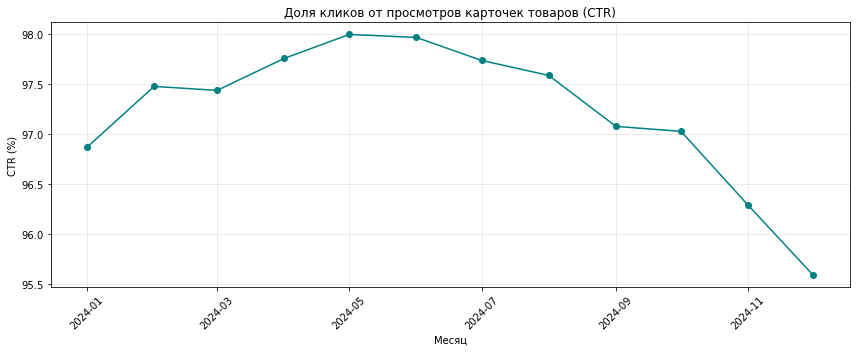

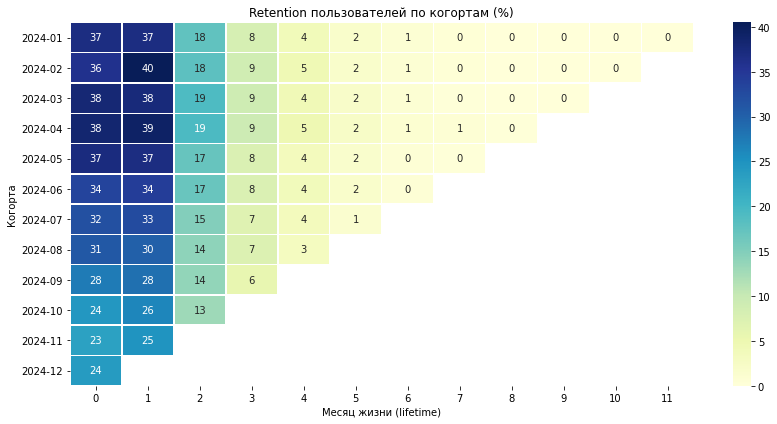

In [132]:
plt.figure(figsize=(12, 5))
plt.plot(metrics['month'], metrics['revenue'], marker='o', color='green')
plt.title('Динамика ежемесячной выручки (5% комиссия)')
plt.ylabel('Выручка')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(dau['event_date'], dau['DAU'], color='red')
plt.title('Ежедневная активность пользователей (DAU)')
plt.ylabel('Уникальных пользователей')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(wau['event_week'], wau['WAU'], color='blue')
plt.title('Еженедельная активность пользователей (WAU)')
plt.ylabel('Уникальных пользователей')
plt.xlabel('Неделя')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(metrics['month'], metrics['active_users'], marker='o', color='blue')
plt.title('Ежемесячная активность пользователей (MAU)')
plt.ylabel('Уникальных пользователей')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(metrics['month'], metrics['ARPU'], marker='o', label='ARPU (все пользователи)')
plt.plot(metrics['month'], metrics['ARPPU'], marker='o', label='ARPPU (платящие)')
plt.title('ARPU и ARPPU')
plt.ylabel('Средний доход')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(metrics['month'], metrics['AOV'], marker='o', color='purple')
plt.title('Средний чек заказа (AOV)')
plt.ylabel('Средний чек')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(metrics['month'], metrics['CR'] * 100, marker='o', color='orange')
plt.title('Конверсия из активного пользователя в платящего (CR)')
plt.ylabel('CR (%)')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(ctr_df['event_month'], ctr_df['CTR_%'], marker='o', color='teal')
plt.title('Доля кликов от просмотров карточек товаров (CTR)')
plt.ylabel('CTR (%)')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(retention_pct, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=0.5)
plt.title('Retention пользователей по когортам (%)')
plt.xlabel('Месяц жизни (lifetime)')
plt.ylabel('Когорта')
plt.tight_layout()
plt.show()

Коротко рассмотрим каждый из визуализаций ключевых метрик:
- `Выручка` росла с января по май и в пике достигла **2.5М**, затем просела в июне и снова выросла до **2.5М** в июле-августе. С сентября виден устойчивый тренд падения до конца периода — в декабре выручка вернулась к уровню февраля и достигла минимума за второе полугодие.
- По `DAU`, `WAU` и `MAU` видна та же картина: показатели росли в первом полугодии, достигли пика летом и с сентября начался спад. Все три метрики активности повторяют динамику выручки.
- `ARPU` падает с мая по декабрь — хотя пользователей стало больше, доход с каждого из них снижается.
- `ARPPU` при этом стабильно держится в диапазоне **1400–1750**. Платящие пользователи стабильны по сумме трат, а падение ARPU объясняется снижением доли платящих среди всех активных.
- `AOV` колеблется с чередованием месяцев роста и падения. С начала года значение выросло с 13 500 до пика ~15 000 в ноябре, после чего снова упало до **13700** в декабре. В целом средний чек стабилен — тревожных сигналов нет.
- По `CR` наблюдается резкое падение с августа: с **40%** до **24%** в декабре. Это говорит о том, что новых пользователей стало больше, но их конверсия в покупку значительно ниже, такое снижение это главный тревожный сигнал данного этапа.
- `CTR` держался стабильно в пределах **97–98%**, к концу года незначительно снизился до **95.5%**. Пользователи кликают на карточки товаров почти всегда — этот показатель в норме.
- `Retention` по когортам: в 0-й и 1-й месяц удержание составляет около **37%**, затем резко падает до **18%** во 2-й месяц и к 5-му месяцу стремится к нулю. Также заметно, что когорты с июля удерживаются хуже ранних уже на первых этапах — новые пользователи возвращаются реже.

### 3. Оценка метрик монетизации и юнит-экономики

In [133]:
orders_cohort = orders_agg.merge(users[['user_id', 'cohort_month']], on='user_id', how='left')

orders_cohort['lifetime_month'] = (
    (orders_cohort['order_month'].dt.year - orders_cohort['cohort_month'].dt.year) * 12 +
    (orders_cohort['order_month'].dt.month - orders_cohort['cohort_month'].dt.month)
)

cohort_revenue = orders_cohort.groupby(['cohort_month', 'lifetime_month'])['revenue'].sum().reset_index()

cohort_size = users.groupby('cohort_month')['user_id'].nunique().reset_index(name='cohort_size')

cohort_ltv = cohort_revenue.merge(cohort_size, on='cohort_month')
cohort_ltv['revenue_per_user'] = cohort_ltv['revenue'] / cohort_ltv['cohort_size']

cohort_ltv = cohort_ltv.sort_values(['cohort_month', 'lifetime_month'])
cohort_ltv['cumulative_ltv'] = cohort_ltv.groupby('cohort_month')['revenue_per_user'].cumsum()

cohort_cac = monthly_costs.merge(monthly_new_users, left_on='spend_month', right_on='cohort_month', how='left')
cohort_cac['CAC'] = cohort_cac['marketing_cost'] / cohort_cac['new_users']
cohort_cac = cohort_cac[['cohort_month', 'CAC']]

cohort_ltv = cohort_ltv.merge(cohort_cac, on='cohort_month', how='left')
cohort_ltv['is_paid_back'] = cohort_ltv['cumulative_ltv'] >= cohort_ltv['CAC']

payback_cohort = (
    cohort_ltv[cohort_ltv['is_paid_back']]
    .groupby('cohort_month')['lifetime_month']
    .min()
    .reset_index(name='payback_month')
)

print(cohort_ltv[['cohort_month', 'lifetime_month', 'cumulative_ltv', 'CAC']].round(2))
print()
print(payback_cohort)

   cohort_month  lifetime_month  cumulative_ltv     CAC
0    2024-01-01             0.0          208.87  394.46
1    2024-01-01             1.0          441.05  394.46
2    2024-01-01             2.0          579.47  394.46
3    2024-01-01             3.0          628.95  394.46
4    2024-01-01             4.0          680.29  394.46
..          ...             ...             ...     ...
68   2024-10-01             1.0          202.14  407.84
69   2024-10-01             2.0          249.41  407.84
70   2024-11-01             0.0           84.91  404.74
71   2024-11-01             1.0          183.34  404.74
72   2024-12-01             0.0           85.47  403.95

[73 rows x 4 columns]

  cohort_month  payback_month
0   2024-01-01            1.0
1   2024-02-01            1.0
2   2024-03-01            1.0
3   2024-04-01            1.0
4   2024-05-01            1.0
5   2024-06-01            1.0
6   2024-07-01            2.0
7   2024-08-01            3.0


In [134]:
print(metrics[['revenue','marketing_cost','AOV', 'ARPU', 'ARPPU', 'CR', 'CAC', 'ROI']].round(2))

       revenue  marketing_cost       AOV    ARPU    ARPPU    CR     CAC   ROI
0    648890.03      1177456.97  13462.45  564.74  1429.27  0.40  394.46 -0.45
1   1296557.01      1061385.93  13526.94  599.70  1545.36  0.39  391.51  0.22
2   1940749.79      1167680.37  13907.20  682.40  1665.88  0.41  393.82  0.66
3   2142838.39      1147739.92  13718.56  700.50  1618.46  0.43  395.09  0.87
4   2478758.10      1225322.28  14091.86  748.87  1765.50  0.42  399.65  1.02
5   2106011.86      1130439.77  13773.79  663.52  1712.20  0.39  402.29  0.86
6   2446535.45      1776446.60  14336.57  702.83  1766.45  0.40  404.84  0.38
7   2465802.40      1811677.75  14534.64  638.64  1780.36  0.36  408.86  0.36
8   1935366.70      1820718.83  14044.75  516.92  1664.12  0.31  407.68  0.06
9   1716108.26      1810802.57  13850.75  479.23  1717.83  0.28  407.84 -0.05
10  1477100.36      1773970.36  14845.23  426.66  1743.92  0.24  404.74 -0.17
11  1342492.41      1858569.86  13733.94  402.43  1671.85  0.24 

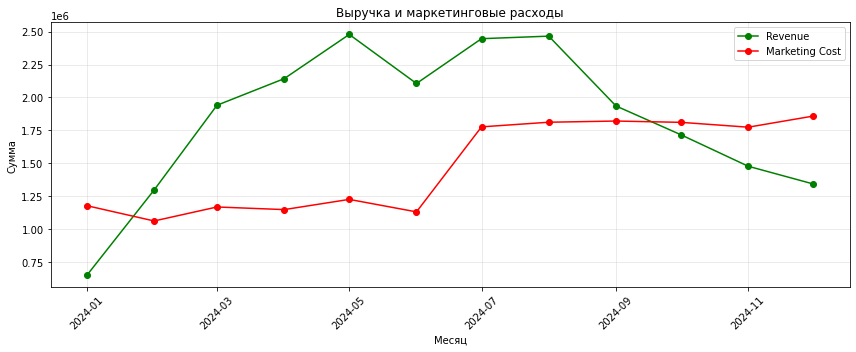

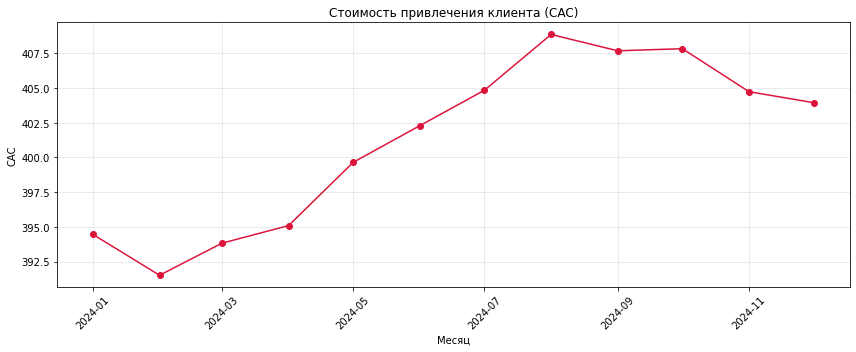

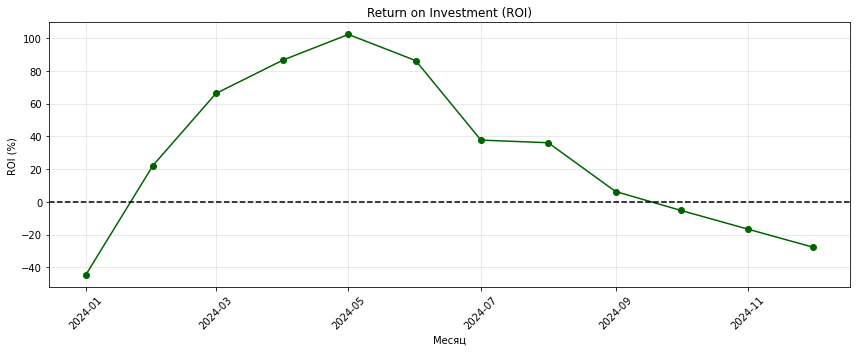

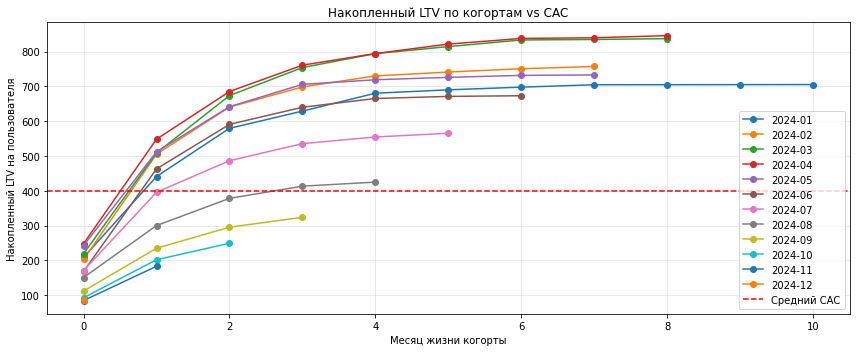

In [135]:
plt.figure(figsize=(12, 5))
plt.plot(metrics['month'], metrics['revenue'], marker='o', label='Revenue', color='green')
plt.plot(metrics['month'], metrics['marketing_cost'], marker='o', label='Marketing Cost', color='red')
plt.title('Выручка и маркетинговые расходы')
plt.ylabel('Сумма')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(metrics['month'], metrics['CAC'], marker='o', color='crimson')
plt.title('Стоимость привлечения клиента (CAC)')
plt.ylabel('CAC')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(metrics['month'], metrics['ROI'] * 100, marker='o', color='darkgreen')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Return on Investment (ROI)')
plt.ylabel('ROI (%)')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for cohort in cohort_ltv['cohort_month'].unique():
    data = cohort_ltv[cohort_ltv['cohort_month'] == cohort]
    plt.plot(data['lifetime_month'], data['cumulative_ltv'], marker='o',
             label=str(cohort)[:7])

plt.axhline(y=cohort_ltv['CAC'].mean(), linestyle='--', color='red', label='Средний CAC')
plt.title('Накопленный LTV по когортам vs CAC')
plt.xlabel('Месяц жизни когорты')
plt.ylabel('Накопленный LTV на пользователя')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Теперь оценим метрики свзанные с монетизацией и юнит-экономикой:
- `Revenue vs Marketing Cost`: в начале года выручка в два раза превышала маркетинговые затраты. Однако затем расходы резко выросли, а выручка осталась на прежнем уровне. С октября маркетинговые расходы превысили выручку, это ключевой сигнал для дальнейшего изучения.
- `CAC` медленно вырос с **393 до 408** за год — каждый новый пользователь стал обходиться немного дороже, чем в начале периода.
- `ROI` также стал ключевым тревожным сигналом: с пика около **100%** в мае он упал до отрицательных значений в октябре–декабре, это означает, что с  сентября маркетинг работает в убыток.
- `Payback Period`: анализ отношения накопленного LTV к CAC показал, что ранние когорты (с января по май) окупались уже на *1–2 месяце* при среднем CAC около 400. Летние когорты окупаются на *2–4 месяце*. Поздние когорты (сентябрь–декабрь), привлечённые преимущественно через `TikTok`, окупаются значительно медленнее, некоторые еще не вышли в плюс к концу наблюдаемого периода. Это дополнительно подтверждает низкое качество TikTok-трафика и необходимость пересмотра бюджетов.

## Выводы по этапам 2 и 3


Выводы по ключевым метрикам и юнит-экономике за период январь-декабрь 2024 года:

Поначалу метрики продукта показывали уверенный рост в первом полугодии, и выручка, и активная аудитория достигли пика к маю 2024, однако с сентября наблюдается устойчивый спад по всем ключевым метрикам, который к декабрю уже несет очень серьезный характер. Главным тревожным сигналом стало `падение CR с 43% в апреле до 24%` в декабре, то есть вдвое за полгода. Пользователи приходят на платформу, но перестают покупать, именно это и тянет выручку вниз, а не снижение среднего чека или уход платящих клиентов, при этом Retention также ухудшается у поздних когорт, с июля новые пользователи возвращаются хуже, чем привлечённые в начале года.

Однако есть и хорошие новости, например, средний чек `AOV стабилен на протяжении всего года`, платящие пользователи не стали тратить меньше, `ARPPU` держится в диапазоне **1400–1750**, `CTR` карточек товаров также держится очень высоко , в районе **96–98%**, это означает, что пользователи охотно кликают на товары и проблема падения второго полугодия точно не в ухудшении контента или качества товаров.

По юнит-экономике ситуация также очень серьезная, с октября `маркетинговые расходы превысили выручку`, `ROI` ушёл в минус, с пиковых значений в районе **100%**, в декабре он составляет около **−30%**. `CAC` также вырос, но не так критично, с 393 до 408, `Payback Period` увеличился с 1-2х месяцев до 3-4х. Продолжать вести такой же маркетинг крайне убыточно, необходимо срочно проанализировать, из-за чего упала конверсия, пересмотреть бюджеты на маркетинг по каналам и сегментам, данная работа будет проведена в следующем блоке.

## 4. Поиск инсайтов, точек роста и сегментация


В рамках этапа 4 проведём детальную сегментацию данных, чтобы найти точки роста, инсайты и выдвинуть гипотезы.
Одной из проблем предыдущего этапа стало повышение затрат на маркетинг, которые не окупались выручкой, поэтому, для начала оценим каналы привлечения, для них посмотрим, какие каналы приводят наиболее качественную аудиторию, а какие тратят бюджет, без окупаемости, сравним по каждому каналу ключевые метрики, а именно выручку, CR, CAC и ROI.

In [136]:
orders_users = orders_agg.merge(users[['user_id', 'acq_channel', 'buyer_segment', 'region']], on='user_id', how='left')

channel_revenue = orders_users.groupby('acq_channel')['revenue'].sum().reset_index(name='revenue')
channel_users = orders_users.groupby('acq_channel')['user_id'].nunique().reset_index(name='paying_users')
channel_all_users = users.groupby('acq_channel')['user_id'].nunique().reset_index(name='total_users')
channel_costs = pa_marketplace_campaign_costs.groupby('acq_channel')['budget'].sum().reset_index(name='marketing_cost')

channel = channel_revenue.merge(channel_users, on='acq_channel') \
                         .merge(channel_all_users, on='acq_channel') \
                         .merge(channel_costs, on='acq_channel', how='left')

channel['ARPPU'] = channel['revenue'] / channel['paying_users']
channel['CR'] = channel['paying_users'] / channel['total_users']
channel['CAC'] = channel['marketing_cost'] / channel['total_users']
channel['ROI'] = (channel['revenue'] - channel['marketing_cost']) / channel['marketing_cost']

print(channel.round(2))

       acq_channel     revenue  paying_users  total_users  marketing_cost  \
0        Affiliate  6735814.78          2338         6069      2012341.39   
1  Email Marketing   555698.74           325         2044       538342.37   
2       Google Ads  8236760.24          3187         9319      4663489.65   
3              SEO  1909934.75           874         3312       661511.58   
4     Social Media  3000254.74          1211         4179      1647396.46   
5           TikTok   910448.21           719        19228      9695376.16   

     ARPPU    CR     CAC   ROI  
0  2881.02  0.39  331.58  2.35  
1  1709.84  0.16  263.38  0.03  
2  2584.49  0.34  500.43  0.77  
3  2185.28  0.26  199.73  1.89  
4  2477.50  0.29  394.21  0.82  
5  1266.27  0.04  504.23 -0.91  


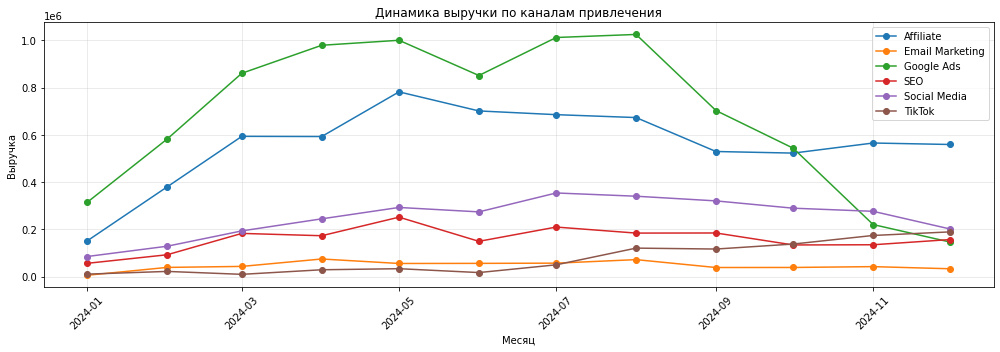

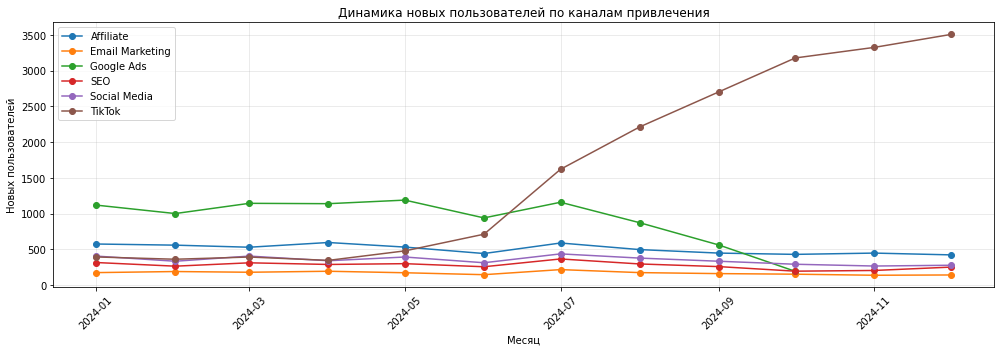

In [137]:
orders_users_monthly = orders_agg.merge(users[['user_id', 'acq_channel', 'cohort_month']], on='user_id', how='left')

channel_monthly_revenue = orders_users_monthly.groupby(['order_month', 'acq_channel'])['revenue'].sum().reset_index()
channel_monthly_users = users.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index()

plt.figure(figsize=(14, 5))
for ch in channel_monthly_revenue['acq_channel'].unique():
    data = channel_monthly_revenue[channel_monthly_revenue['acq_channel'] == ch]
    plt.plot(data['order_month'], data['revenue'], marker='o', label=ch)
plt.title('Динамика выручки по каналам привлечения')
plt.ylabel('Выручка')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
for ch in channel_monthly_users['acq_channel'].unique():
    data = channel_monthly_users[channel_monthly_users['acq_channel'] == ch]
    plt.plot(data['cohort_month'], data['user_id'], marker='o', label=ch)
plt.title('Динамика новых пользователей по каналам привлечения')
plt.ylabel('Новых пользователей')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

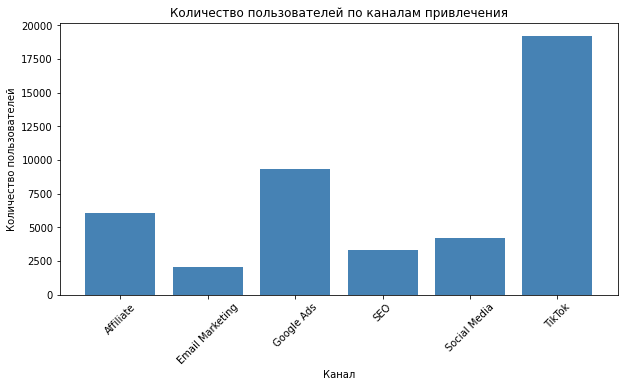

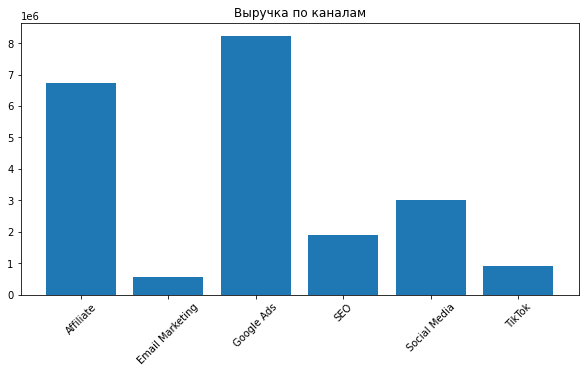

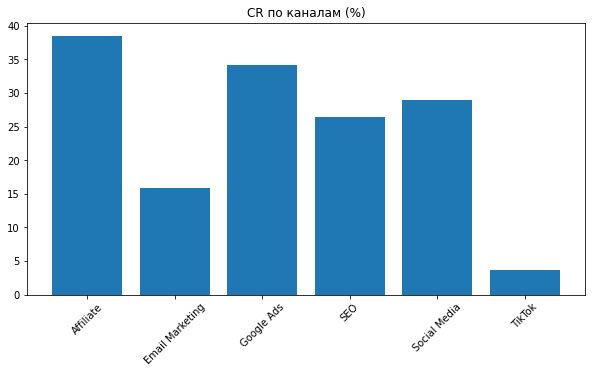

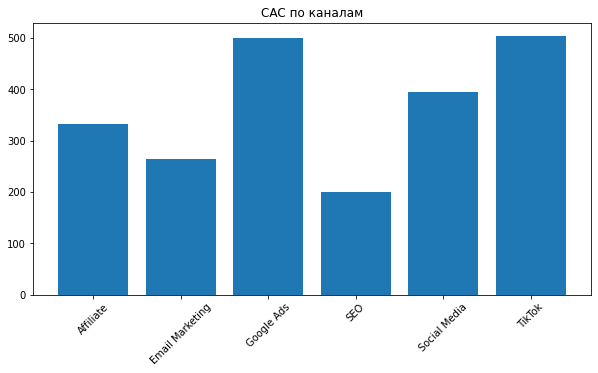

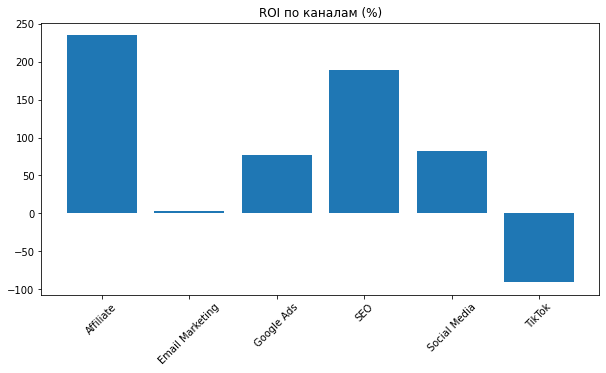

In [138]:
plt.figure(figsize=(10, 5))
plt.bar(channel['acq_channel'], channel['total_users'], color='steelblue')
plt.title('Количество пользователей по каналам привлечения')
plt.ylabel('Количество пользователей')
plt.xlabel('Канал')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(channel['acq_channel'], channel['revenue'])
plt.title('Выручка по каналам')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(channel['acq_channel'], channel['CR'] * 100)
plt.title('CR по каналам (%)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(channel['acq_channel'], channel['CAC'])
plt.title('CAC по каналам')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(channel['acq_channel'], channel['ROI'] * 100)
plt.title('ROI по каналам (%)')
plt.xticks(rotation=45)
plt.show()

Коротко оценим визуализацию ключевых метрик по каналам привлечения:
Сразу видна ключевая проблема, канал привлечения `TikTok` поглощает больше половины маркетингового бюджета **9.7М из примерно 19М** при **ROI −91% и CR всего 4%**, стало понятно, что канал приводит много пользователей, но такая аудитория крайне не заинтересована в продукте, почти никто не покупает и не становится клиентом. Лучшие каналы по эффективности - это `Affiliate` с метриками **ROI 235%, CR 39%** и `SEO` с метриками **ROI 189%, CAC 200**, они дают качественную аудиторию с низкой стоимостью привлечения, при этом `Google Ads` и `Social Media` также работают в плюс, но уже с меньшей отдачей, а `Email Marketing` едва ли окупается.

Динамика по месяцам также показала важный контекст. С июня начался явный сдвиг в стратегии в пользу `TikTok`, привличения начали увеличиваться и к декабрю цифры составляют уже 3500 новых пользователей в месяц, также видно, что сотрудничество с `Google Ads` остановлено к октябрю. Скорее всего бюджет именно оттуда перенесли в `TikTok`.

Когортный анализ накопительного LTV к CAC подтвердил это, ранние когорты с января по май окупались уже на 1–2 месяце жизни при среднем CAC около 400. Летние когорты выходили в плюс на 2–4 месяце. Поздние когорты (сентябрь–декабрь), привлечённые преимущественно через `TikTok`, окупаются значительно медленнее.

Теперь посмотрим на сегменты пользователей. В данных есть разбивка на 4 типа покупателей: `regular`, `medium`, `rare` и `one_time`. Целью является понять, какой сегмент приносит основную выручку и где сосредоточен нереализованный потенциал.

In [139]:
segment_revenue = orders_users.groupby('buyer_segment')['revenue'].sum().reset_index(name='revenue')
segment_users = orders_users.groupby('buyer_segment')['user_id'].nunique().reset_index(name='paying_users')
segment_all = users.groupby('buyer_segment')['user_id'].nunique().reset_index(name='total_users')

segment = segment_revenue.merge(segment_users, on='buyer_segment').merge(segment_all, on='buyer_segment')
segment['ARPPU'] = segment['revenue'] / segment['paying_users']
segment['CR'] = segment['paying_users'] / segment['total_users']
print(segment.round(2))

  buyer_segment      revenue  paying_users  total_users    ARPPU    CR
0        medium   5190507.73          3692        16421  1405.88  0.22
1      one_time    221051.71           258         6701   856.79  0.04
2          rare   1046909.80           988        13256  1059.63  0.07
3       regular  14890442.21          3716         7773  4007.12  0.48


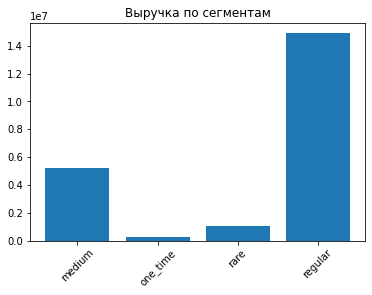

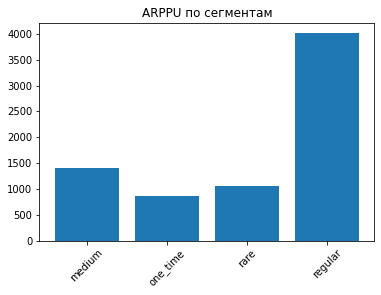

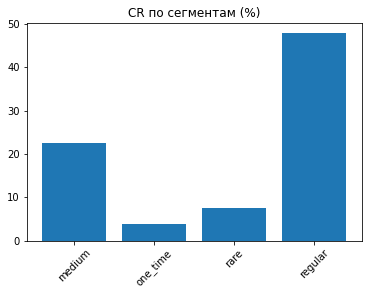

In [140]:
plt.figure(figsize=(6,4))
plt.bar(segment['buyer_segment'], segment['revenue'])
plt.title('Выручка по сегментам')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,4))
plt.bar(segment['buyer_segment'], segment['ARPPU'])
plt.title('ARPPU по сегментам')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,4))
plt.bar(segment['buyer_segment'], segment['CR'] * 100)
plt.title('CR по сегментам (%)')
plt.xticks(rotation=45)
plt.show()

После просмотра визуализаций сделаем короткий вывод:

Сегмент `regular` это самый важный для компании сегмент, его ключевые метрики: **CR 48%, ARPPU 4007, выручка 14.9М**, что составляет около **70% от общей**. При этом пользователей, которые относятся к этому сегменту, почти меньше всех, всего 7773. Сегменты `rare` и `one_time` вместе составляют около 45% всей базы пользователей, вместе почти 20 тысяч пользователей, но приносят они менее **6%** выручки. Тут виден огромный потенциал для повышения выручки, если хотя бы часть из них перейдет в сегменты повыше, выручка заметно вырастет.

Следующий срез, который мы рассмотрим, это категории товаров. Посмотрим, какие из них дают больше всего выручки и какой у них средний чек. Это поможет понять, на каких категориях стоит акцентировать внимание маркетинговому отделу.

In [141]:
category_revenue = orders.groupby('category_name')['revenue'].sum().reset_index(name='revenue')
category_orders = orders.groupby('category_name')['order_id'].nunique().reset_index(name='orders_count')
category_aov = orders.groupby('category_name')['total_price'].mean().reset_index(name='AOV')

category = category_revenue.merge(category_orders, on='category_name').merge(category_aov, on='category_name')
category = category.sort_values('revenue', ascending=False)
print(category.round(2))

                      category_name     revenue  orders_count       AOV
11                  Мебель для дома  3580998.22           979  73156.25
2                   Бытовая техника  2248933.06          1030  43668.60
24                 Украшения и часы  1718297.10          1024  33560.49
18             Спортивный инвентарь  1165361.15          1000  23307.22
23               Товары для туризма  1137317.79           970  23449.85
0                        Автотовары  1044821.74          1043  20034.93
21                 Товары для кухни  1030401.81          1237  16659.69
15                    Обувь мужская   942481.68          1253  15043.60
20               Сумки и аксессуары   873491.14          1180  14804.93
14                    Обувь женская   860489.19          1211  14211.22
8   Инструменты и садовый инвентарь   812372.79          1000  16247.46
3                 Декор и освещение   703803.57          1053  13367.59
1           Аксессуары для гаджетов   693470.27          1255  1

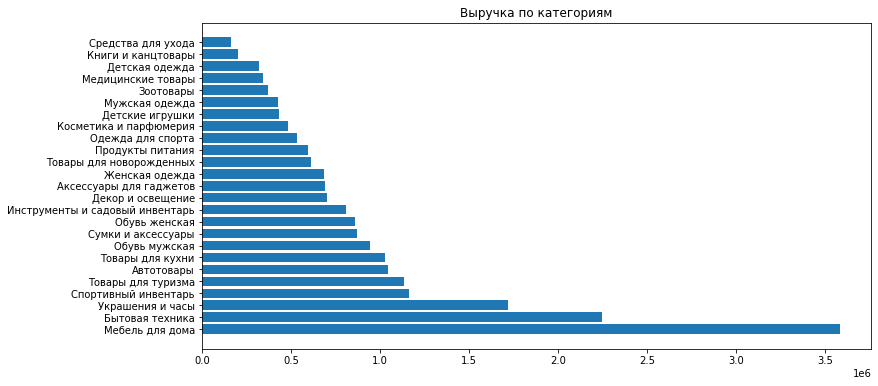

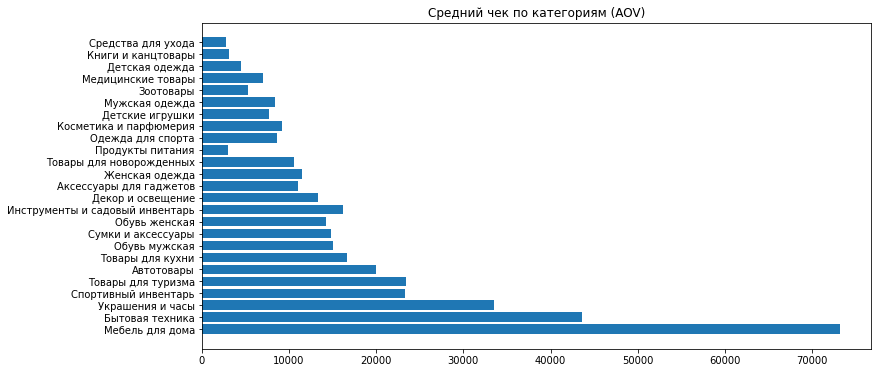

In [142]:
plt.figure(figsize=(12,6))
plt.barh(category['category_name'], category['revenue'])
plt.title('Выручка по категориям')
plt.show()

plt.figure(figsize=(12,6))
plt.barh(category['category_name'], category['AOV'])
plt.title('Средний чек по категориям (AOV)')
plt.show()

После анализа визуализаций сделаю краткий вывод:

В топ-3 категории попали: `Мебель для дома (3.58М, AOV 73К)`, `Бытовая техника (2.25М, AOV 44К)` и `Украшения и часы (1.72М, AOV 34К)`, вместе они дают около **35%** всей выручки при относительно небольшом количестве заказов, именно эти категории и дают большую маржу для маркетплейса. Категория с самым большим количеством заказов, это `Продукты питания` с количеством заказов **4027, но AOV всего 2962 и средняя выручка 596 тысяч**, метрики такие из-за того, что это низкомаржинальный продукт, из-за маленьких комиссий с каждого заказа, с которых и зарабатывает маркетплейс.

Теперь перейдём к географическому срезу, здесь проверим, отличается ли качество аудитории по регионам используя метрики `выручка, конверсия, средний доход на платящего пользователя`. Это покажет, нужно ли делать раздельный маркетинг по регионам.

In [143]:
region_revenue = orders_users.groupby('region')['revenue'].sum().reset_index(name='revenue')
region_users = orders_users.groupby('region')['user_id'].nunique().reset_index(name='paying_users')
region_all = users.groupby('region')['user_id'].nunique().reset_index(name='total_users')

region = region_revenue.merge(region_users, on='region').merge(region_all, on='region')
region['ARPPU'] = region['revenue'] / region['paying_users']
region['CR'] = region['paying_users'] / region['total_users']
region = region.sort_values('revenue', ascending=False)
print(region.round(2))

               region     revenue  paying_users  total_users    ARPPU    CR
0      Другие регионы  6837361.32          2816        14516  2428.04  0.19
3              Москва  5410184.15          2200        10959  2459.17  0.20
8     Санкт-Петербург  3396292.57          1317         6690  2578.81  0.20
4  Московская область  1658614.02           681         3549  2435.56  0.19
1        Екатеринбург  1143765.90           418         2145  2736.28  0.19
5     Нижний Новгород   841422.00           354         1748  2376.90  0.20
2           Краснодар   728837.63           290         1398  2513.23  0.21
6         Новосибирск   728729.05           310         1723  2350.74  0.18
7      Ростов-на-Дону   603704.79           268         1423  2252.63  0.19


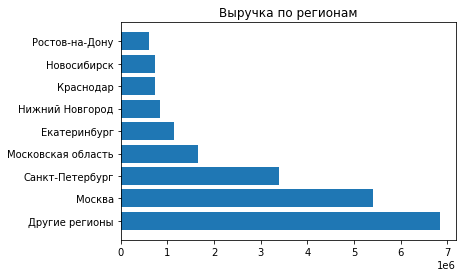

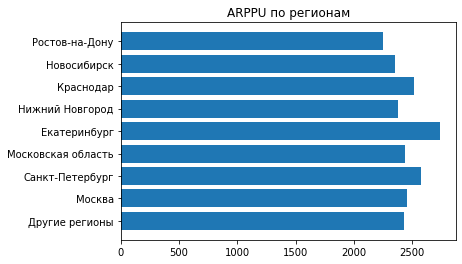

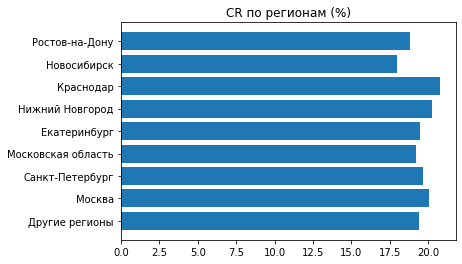

In [144]:
plt.figure(figsize=(6,4))
plt.barh(region['region'], region['revenue'])
plt.title('Выручка по регионам')
plt.show()

plt.figure(figsize=(6,4))
plt.barh(region['region'], region['ARPPU'])
plt.title('ARPPU по регионам')
plt.show()

plt.figure(figsize=(6,4))
plt.barh(region['region'], region['CR'] * 100)
plt.title('CR по регионам (%)')
plt.show()

После анализа визуализаций, сделаю короткий вывод:

Регионы оказались самым сбалансированным сегментом, здесь ARPPU и CR практически одинаковы везде, **19–21% CR, 2250–2740 ARPPU**. Разница в выручке между регионами объясняется только размером аудитории, а не качеством привлеченных пользователей. Это означает, что каждый регион может дать практически идентичную аудиторию, поэтому стоит рассматривать масштабирование в другие крупные города.

Далее посмотрим на поведение пользователей в разрезе типов устройств — `desktop, mobile и tablet`. Проверим, влияет ли тип устройства на `конверсию и доход`.

In [145]:
device_events = events.groupby('device')['user_id'].nunique().reset_index(name='active_users')
device_orders = orders_agg.merge(events[['user_id', 'device']].drop_duplicates(), on='user_id')
device_revenue = device_orders.groupby('device')['revenue'].sum().reset_index(name='revenue')
device_paying = device_orders.groupby('device')['user_id'].nunique().reset_index(name='paying_users')

device = device_events.merge(device_revenue, on='device').merge(device_paying, on='device')
device['CR'] = device['paying_users'] / device['active_users']
device['ARPPU'] = device['revenue'] / device['paying_users']
print(device.round(2))

    device  active_users     revenue  paying_users    CR    ARPPU
0  desktop          7447  6547252.32          2428  0.33  2696.56
1   mobile          7431  6678642.78          2493  0.34  2678.96
2   tablet          7260  6795250.25          2377  0.33  2858.75


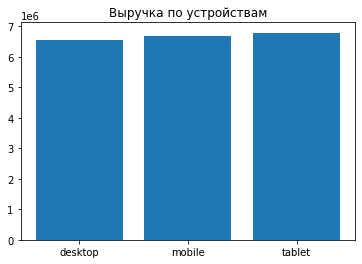

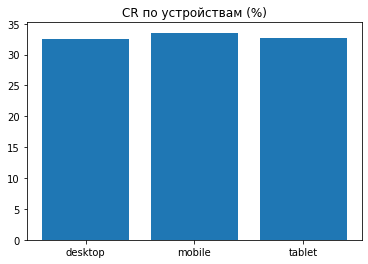

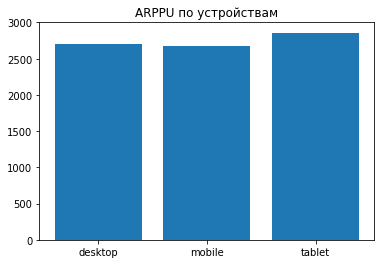

In [146]:
plt.figure(figsize=(6,4))
plt.bar(device['device'], device['revenue'])
plt.title('Выручка по устройствам')
plt.show()

plt.figure(figsize=(6,4))
plt.bar(device['device'], device['CR'] * 100)
plt.title('CR по устройствам (%)')
plt.show()

plt.figure(figsize=(6,4))
plt.bar(device['device'], device['ARPPU'])
plt.title('ARPPU по устройствам')
plt.show()

После анализа визуализаций сделаю короткий вывод: 

Устройства также не показали значимых различий в метриках, все три типа устройств демонстрируют идентичные показатели CR 33% и ARPPU 2700. Аудитория равномерно распределена по девайсам и одинаково дает конверсию. Поэтому в утройствах никаких проблем нет, но и точек роста обнаружить сложно.

Наконец, завершим сегментацию анализом воронки событий. Посмотрим, на каких шагах пути к покупке теряется больше всего пользователей. Дополнительно проверим воронку в разрезе устройств и каналов привлечения, чтобы понять, является ли проблема общей или связана с конкретным типом устройств и каналов.

In [147]:
funnel_steps = ['page_view', 'product_view', 'product_click', 'add_to_cart', 'checkout_start', 'checkout_complete']

funnel_counts = (
    events[events['event_type'].isin(funnel_steps)]
    .groupby('event_type')['user_id']
    .nunique()
    .reindex(funnel_steps)
    .reset_index()
)
funnel_counts.columns = ['step', 'users']
funnel_counts['conversion_from_first_%'] = (funnel_counts['users'] / funnel_counts['users'].iloc[0] * 100).round(1)
funnel_counts['conversion_from_prev_%'] = (funnel_counts['users'] / funnel_counts['users'].shift(1) * 100).round(1)
print(funnel_counts)

                step  users  conversion_from_first_%  conversion_from_prev_%
0          page_view  22098                    100.0                     NaN
1       product_view  22069                     99.9                    99.9
2      product_click  21745                     98.4                    98.5
3        add_to_cart  20411                     92.4                    93.9
4     checkout_start  16769                     75.9                    82.2
5  checkout_complete  13897                     62.9                    82.9


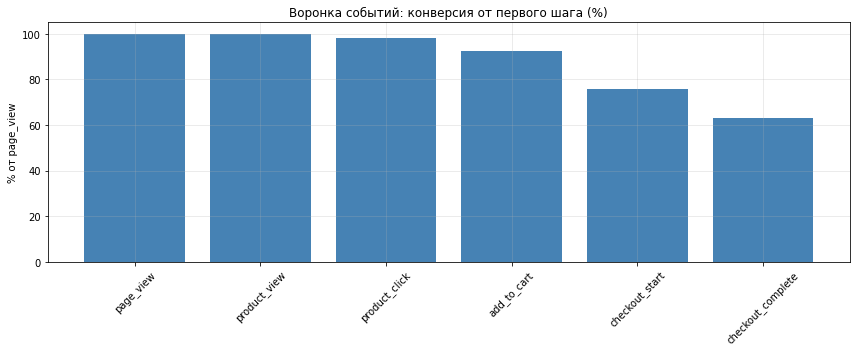

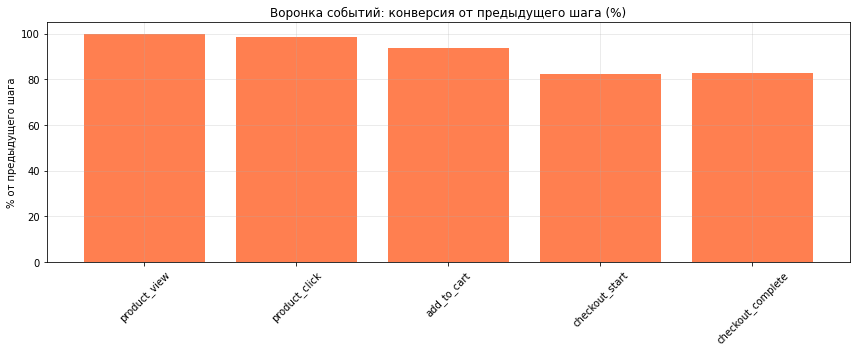

In [148]:
plt.figure(figsize=(12, 5))
plt.bar(funnel_counts['step'], funnel_counts['conversion_from_first_%'], color='steelblue')
plt.title('Воронка событий: конверсия от первого шага (%)')
plt.ylabel('% от page_view')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(funnel_counts['step'][1:], funnel_counts['conversion_from_prev_%'][1:], color='coral')
plt.title('Воронка событий: конверсия от предыдущего шага (%)')
plt.ylabel('% от предыдущего шага')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [149]:
records = []

for device_name in events['device'].unique():
    device_events = events[events['device'] == device_name]
    
    counts = (
        device_events[device_events['event_type'].isin(funnel_steps)]
        .groupby('event_type')['user_id']
        .nunique()
        .reindex(funnel_steps)
        .reset_index()
    )
    counts.columns = ['step', 'users']
    counts['device'] = device_name
    counts['conversion_from_first_%'] = (counts['users'] / counts['users'].iloc[0] * 100).round(1)
    counts['conversion_from_prev_%'] = (counts['users'] / counts['users'].shift(1) * 100).round(1)
    records.append(counts)

funnel_by_device = pd.concat(records, ignore_index=True)
print(funnel_by_device)

                 step  users   device  conversion_from_first_%  \
0           page_view   7423   mobile                    100.0   
1        product_view   7413   mobile                     99.9   
2       product_click   7309   mobile                     98.5   
3         add_to_cart   6848   mobile                     92.3   
4      checkout_start   5572   mobile                     75.1   
5   checkout_complete   4607   mobile                     62.1   
6           page_view   7431  desktop                    100.0   
7        product_view   7419  desktop                     99.8   
8       product_click   7308  desktop                     98.3   
9         add_to_cart   6858  desktop                     92.3   
10     checkout_start   5697  desktop                     76.7   
11  checkout_complete   4766  desktop                     64.1   
12          page_view   7244   tablet                    100.0   
13       product_view   7237   tablet                     99.9   
14      pr

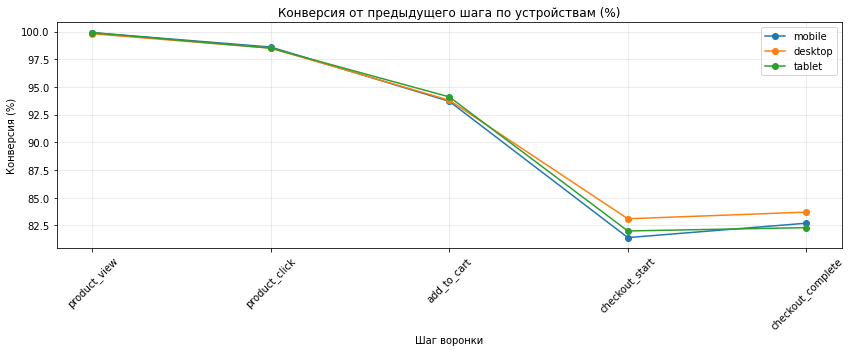

In [150]:
plt.figure(figsize=(12, 5))
for device_name in funnel_by_device['device'].unique():
    data = funnel_by_device[funnel_by_device['device'] == device_name]
    plt.plot(data['step'][1:], data['conversion_from_prev_%'][1:], marker='o', label=device_name)

plt.title('Конверсия от предыдущего шага по устройствам (%)')
plt.ylabel('Конверсия (%)')
plt.xlabel('Шаг воронки')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [151]:
events_channel = events.merge(users[['user_id', 'acq_channel']], on='user_id', how='left')

records = []

events_channel = events_channel[events_channel['acq_channel'].notna()]
for channel_name in events_channel['acq_channel'].unique():
    channel_data = events_channel[events_channel['acq_channel'] == channel_name]
    
    counts = (
        channel_data[channel_data['event_type'].isin(funnel_steps)]
        .groupby('event_type')['user_id']
        .nunique()
        .reindex(funnel_steps)
        .reset_index()
    )
    counts.columns = ['step', 'users']
    counts['acq_channel'] = channel_name
    counts['conversion_from_first_%'] = (counts['users'] / counts['users'].iloc[0] * 100).round(1)
    counts['conversion_from_prev_%'] = (counts['users'] / counts['users'].shift(1) * 100).round(1)
    records.append(counts)

funnel_by_channel = pd.concat(records, ignore_index=True)
print(funnel_by_channel)

                 step  users      acq_channel  conversion_from_first_%  \
0           page_view   3676        Affiliate                    100.0   
1        product_view   3674        Affiliate                     99.9   
2       product_click   3638        Affiliate                     99.0   
3         add_to_cart   3531        Affiliate                     96.1   
4      checkout_start   3136        Affiliate                     85.3   
5   checkout_complete   2774        Affiliate                     75.5   
6           page_view   6651           TikTok                    100.0   
7        product_view   6631           TikTok                     99.7   
8       product_click   6438           TikTok                     96.8   
9         add_to_cart   5649           TikTok                     84.9   
10     checkout_start   3849           TikTok                     57.9   
11  checkout_complete   2633           TikTok                     39.6   
12          page_view   5611       Goo

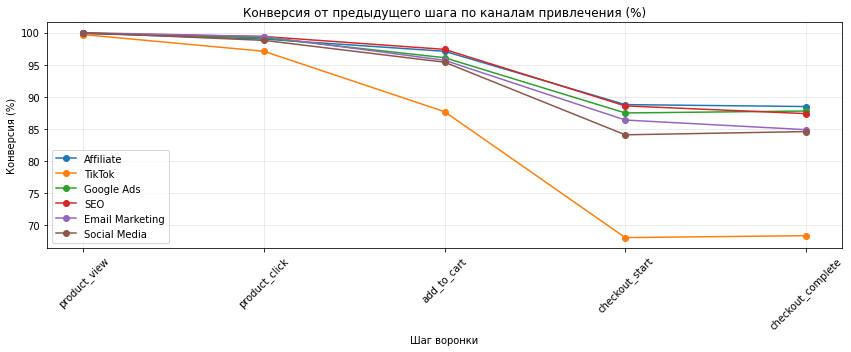

In [152]:
plt.figure(figsize=(12, 5))
for channel_name in funnel_by_channel['acq_channel'].unique():
    data = funnel_by_channel[funnel_by_channel['acq_channel'] == channel_name]
    plt.plot(data['step'][1:], data['conversion_from_prev_%'][1:], marker='o', label=channel_name)

plt.title('Конверсия от предыдущего шага по каналам привлечения (%)')
plt.ylabel('Конверсия (%)')
plt.xlabel('Шаг воронки')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

После анализа графиков сделаем небольшой вывод:
    
Воронка показывает хорошие результаты на первых шагах, а именно `от page_view до add_to_cart` теряется всего **7–8%** пользователей, а дальше мы видим два падения на последних этапах, `с add_to_cart в checkout_start теряется около 18% пользователей и из checkout_start в checkout_complete ещё примерно 17%`.
Однако проверка воронки по каналам привлечения показала, что проблема не одинакова для всех, проблема опять же в канале `TikTok`, здесь резко проседает именно шаге `add_to_cart в checkout_start`, конверсия составляет всего **68.1%** против **86–88%** у остальных каналов. До корзины пользователи `TikTok` доходят нормально, но заказ не оформляют, это подтверждает некачественность аудитории из этого канала.
Проверка воронки по устройствам показала, что разброс между `mobile, desktop и tablet` не превышает **1–2** процентный пункта, проблема оформления заказа не связана с типом девайса.

## Выводы по этапу 4

Выводы по этапу 4, реализованному в качестве аналитической записки:

На 4 этапе был проведен детальный анализ ключевых сегментов аудитории и выявлены некоторые важные проблемы, рассмотрим каждый шаг:

**Каналы привлечения**

Анализ каналов выявил главную причину падения ROI продукта, канал привлечения **TikTok расходует более 50% маркетингового бюджета (9.7М из 19М) при ROI −91% и CR всего 4%**. Он приводит самую большую аудиторию **(19228 пользователей)**, но почти никто из них не становятся платящими клиентами, это подтвердил и анализ воронки по каналам, именно `TikTok` резко проседает на шаге из `add_to_cart в checkout_start` *(68.1% против 86–88% у остальных каналов)*, пользователи добавляют товары в корзину, часто но не оформляют заказ, это и показывает некачественность аудитории из этого канала. 

Лучшими каналами по эффективности являются **Affiliate (ROI 235%, CR 39%)** и **SEO (ROI 189%, CAC 200)**. Оба дают качественную аудиторию с низкой стоимостью привлечения и высокой конверсией, при этом `Google Ads` и `Social Media` также работают в плюс, но с умеренной отдачей. `Email Marketing` же едва окупается, ROI составляет 3%.

**Сегменты пользователей**

Сегмент `regular` — это самый важный для компании сегмент, его ключевые метрики: **CR 48%, ARPPU 4007, выручка 14.9М**, что составляет около **70% от общей**. При этом пользователей в этом сегменте почти меньше всех, всего 7773. Сегменты `rare` и `one_time` вместе составляют около **45%** всей базы, что почти *20 тысяч* пользователей, но приносят менее **6%** выручки. Тут виден огромный потенциал — если хотя бы часть из них перейдёт в сегменты повыше, выручка заметно вырастет.

**Категории товаров**

В топ-3 категории попали `Мебель для дома (3.58М, AOV 73К)`, `Бытовая техника (2.25М, AOV 44К)` и `Украшения и часы (1.72М, AOV 34К)` — вместе они дают около **35%** всей выручки при относительно небольшом количестве заказов, именно эти категории приносят наибольшую маржу маркетплейсу за счёт высокого чека. Категория с самым большим количеством заказов — `Продукты питания`, у них **4027 заказов, AOV всего 2962 и выручка 596 тысяч**. Это низкомаржинальный продукт с маленькими комиссиями с каждого заказа, поэтому несмотря на высокую частоту покупок выручка от него средняя.

**Регионы и устройства**

Оба среза оказались самыми сбалансированными, среди них никаких значимых различий не обнаружено. Регионы показывают практически одинаковые **CR 19–21% и ARPPU 2250–2740**, разница в выручке между ними объясняется только размером аудитории, а не её качеством. То же самое с устройствами, в них все три типа демонстрируют идентичные **CR 33% и ARPPU 2700**, аудитория равномерно распределена и показывает одинаковую конверсию на любом девайсе. Точек роста в этих срезах нет, но и проблем тоже.

**Воронка событий**

Воронка показывает хорошие результаты на первых шагах, от `page_view` до `add_to_cart` теряется всего **7–8%** пользователей. Дальше видим два падения на последних этапах: с `add_to_cart` в `checkout_start` теряется около **18%** пользователей, и из `checkout_start` в `checkout_complete` ещё примерно **17%**. Анализ воронки по типам устройств и каналам привлечения выделил TikTok, о котором было написано ранее, если его убрать из расчёта, воронка остальных каналов выглядит заметно лучше и ровнее — проблема оформления заказа во многом объясняется низким качеством трафика из этого канала. Проверка по устройствам подтвердила, что тип девайса на воронку не влияет, разброс между устройствами не превышает **1–2 процентных пункта.**

**Гипотезы для развития продукта**

**1. Если перераспределить бюджет с TikTok на Affiliate и SEO, то ROI маркетинга вернётся в зону окупаемости.**

*На что опирается гипотеза:* TikTok тратит более 50% маркетингового бюджета при ROI −91% и CR всего 4%, в этом заключается главная причина падения общего ROI продукта. Воронка показала, что пользователи TikTok добавляют товары в корзину, но не оформляют заказ. Канал Affiliate при этом даёт ROI 235% и CR 39%, а SEO дает ROI 189% при самом низком CAC = 200.

**2. Если запустить программу возвращения для сегментов rare и one_time через специальные личные письма, персональные скидки и акции или напоминания, то часть из них перейдёт в более активные сегменты и выручка вырастет.**

*На что опирается гипотеза:* сегменты rare и one_time вместе - это почти 20 тысяч пользователей, которые уже знакомились с продуктом, но почти не покупают или давно не совершали покупки, метрика CR = 4–7%, и если часть аудитории удастся вернуть и поднять до уровня medium, где CR уже 22%, прирост выручки будет заметным.

**3. Если разработать персональные акции и предложения по категориям `Мебель для дома` и `Бытовая техника` для каналов привлечения `Affiliate` и `SEO`, то выручка от этих категорий вырастет засчет увеличения заказов.**

*На что опирается гипотеза:* категории Мебель для дома и Бытовая техника дают около 27% всей выручки при AOV в 3–5 раз выше среднего по платформе, следовательно один дополнительный заказ мебели приносит столько же, сколько 5 заказов из низкочековых категорий, а каналы Affiliate и SEO демонстрируют самую высокую конверсию и приводят самую качественную аудиторию CR 39% и 26% соответственно при низком CAC, относительно `Google Ads`. Персональные акции именно для этой аудитории в высокомаржинальных категориях дадут максимальный эффект на увеличение выручки.

**4. Если добавить механику пуш-уведомлений о брошенной корзине и снижении цены на товары из корзины, то конверсия на шаге из `add_to_cart в checkout_start` вырастет.**

*На что опирается гипотеза:* воронка теряет около 18% пользователей именно на этом шаге, и проблема общая для всех сегментов, она не зависит ни от устройства, ни от региона, часть пользователей добавляет товары в корзину, но откладывает покупку и не возвращается. Напоминание о брошенной корзине и изменении цены подтолкнет пользователей завершить заказ и простимулирует не упустить выгоду.

**5. Если запустить специальные условия или бонусы для пользователей при оформлении заказа (например, скидка на первый заказ от определённой суммы или бесплатная доставка от определенной суммы), то конверсия на шаге из`checkout_start в checkout_complete` вырастет.**

*На что опирается гипотеза:* воронка теряет ещё около 17% пользователей на финальном шаге, когда человек начал оформлять, но не завершил покупку по каким-то причинам. Если клиента останавливает стоимость доставки или цена товара, можно таким образом подтолкнуть его к совершению целевого действия.

## 5. Подготовка эксперимента и подведение его результатов

In [153]:
events_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_events_AB.csv',
                        parse_dates=['event_date', 'event_week', 'event_month'])

orders_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_orders_AB.csv',
                        parse_dates=['order_date', 'order_week', 'order_month'])

sessions_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_sessions_AB.csv',
                          parse_dates=['session_start', 'session_week', 'session_month'])

users_ab = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_users_AB.csv',
                       parse_dates=['registration_date', 'cohort_week', 'cohort_month'])

split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_AB_split_users.csv')

In [154]:
dfs = {
    'events_ab': events_ab,
    'orders_ab': orders_ab,
    'sessions_ab': sessions_ab,
    'users_ab': users_ab,
    'split_users': split_users
}

for name, df in dfs.items():
    print(f'Название таблицы - {name}')
    display(df.head())
    print()

for name, df in dfs.items():
    print(f'{name}')
    print(f'Строк: {len(df):,}')
    print(f'Столбцы: {list(df.columns)}')
    print()

for name, df in dfs.items():
    print(f'{name} — пропуски по столбцам:')
    print(df.isnull().sum())
    print()

for name, df in dfs.items():
    print(f'{name}: дубликатов = {df.duplicated().sum()}')

Название таблицы - events_ab


,event_id,session_id,user_id,event_date,event_type,os,device,event_index,user_segment,product_name,event_week,event_month
0,3132,479,100,2024-01-01 15:23:56,page_view,iOS,mobile,1,regular,NaN,2024-01-01,2024-01-01
1,3133,479,100,2024-01-01 15:24:01,product_view,iOS,mobile,2,regular,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,479,100,2024-01-01 15:24:10,product_click,iOS,mobile,3,regular,Куртка детская,2024-01-01,2024-01-01
3,3135,479,100,2024-01-01 15:25:10,add_to_cart,iOS,mobile,4,regular,Балетки классические,2024-01-01,2024-01-01
4,3136,479,100,2024-01-01 15:25:46,checkout_start,iOS,mobile,5,regular,NaN,2024-01-01,2024-01-01



Название таблицы - orders_ab


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01



Название таблицы - sessions_ab


...


Название таблицы - users_ab


,user_id,registration_date,os,age,device,gender,region,browser,country,acq_channel,campaign_id,user_segment,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,Android,49,mobile,M,Екатеринбург,Edge,Россия,TikTok,10.0,спящий,one_time,2024-01-01,2024-01-01
1,22,2024-01-01 17:13:00,iOS,50,tablet,M,Санкт-Петербург,Chrome,Россия,TikTok,43.0,VIP,one_time,2024-01-01,2024-01-01
2,26,2024-01-01 21:15:00,iOS,60,desktop,F,Москва,Firefox,Россия,TikTok,27.0,активный,rare,2024-01-01,2024-01-01
3,33,2024-01-01 14:43:00,iOS,31,desktop,M,Екатеринбург,Firefox,Россия,TikTok,15.0,новичок,rare,2024-01-01,2024-01-01
4,39,2024-01-01 01:13:00,Android,44,tablet,M,Санкт-Петербург,Firefox,Россия,TikTok,15.0,спящий,rare,2024-01-01,2024-01-01



Название таблицы - split_users


,user_id,group
0,44965,control
1,44967,control
2,44968,control
3,44969,treatment
4,44970,control



events_ab
Строк: 831,231
Столбцы: ['event_id', 'session_id', 'user_id', 'event_date', 'event_type', 'os', 'device', 'event_index', 'user_segment', 'product_name', 'event_week', 'event_month']

orders_ab
Строк: 33,280
Столбцы: ['order_id', 'user_id', 'order_date', 'product_name', 'quantity', 'unit_price', 'total_price', 'category_name', 'order_week', 'order_month']

sessions_ab
Строк: 127,407
Столбцы: ['session_id', 'user_id', 'session_start', 'os', 'device', 'region', 'browser', 'country', 'entry_path', 'path_start', 'utm_source', 'screen_size', 'scroll_depth', 'user_segment', 'utm_campaign_id', 'session_week', 'session_month']

users_ab
Строк: 22,196
Столбцы: ['user_id', 'registration_date', 'os', 'age', 'device', 'gender', 'region', 'browser', 'country', 'acq_channel', 'campaign_id', 'user_segment', 'buyer_segment', 'cohort_week', 'cohort_month']

split_users
Строк: 2,968
Столбцы: ['user_id', 'group']

events_ab — пропуски по столбцам:
event_id             0
session_id           0
u

In [155]:
print('events_ab:', events_ab['event_date'].min(), '—', events_ab['event_date'].max())
print('orders_ab:', orders_ab['order_date'].min(), '—', orders_ab['order_date'].max())
print('sessions_ab:', sessions_ab['session_start'].min(), '—', sessions_ab['session_start'].max())
print('users_ab:', users_ab['registration_date'].min(), '—', users_ab['registration_date'].max())

print('\nПользователей в users_ab:', users_ab['user_id'].nunique())
print('Пользователей в split_users:', split_users['user_id'].nunique())
print('Пересечение:', users_ab['user_id'].isin(split_users['user_id']).sum())
print('\nКаналы в users_ab:', users_ab['acq_channel'].unique())

events_ab: 2024-01-01 15:23:56 — 2025-01-26 23:59:34
orders_ab: 2024-01-01 08:03:45 — 2025-01-26 23:07:50
sessions_ab: 2024-01-01 08:34:27 — 2025-01-26 23:58:24
users_ab: 2024-01-01 01:13:00 — 2025-01-26 23:41:00

Пользователей в users_ab: 22196
Пользователей в split_users: 2968
Пересечение: 2968

Каналы в users_ab: ['TikTok']


In [156]:
print('Тестовых пользователей:', split_users['user_id'].nunique())
print(split_users['group'].value_counts())
print('Пересечений между группами:', (split_users.groupby('user_id')['group'].nunique() > 1).sum())

test_reg = users_ab[users_ab['user_id'].isin(split_users['user_id'])].merge(split_users, on='user_id')
print('\nПериод регистрации control:', test_reg[test_reg['group'] == 'control']['registration_date'].min(),
      '—', test_reg[test_reg['group'] == 'control']['registration_date'].max())
print('Период регистрации treatment:', test_reg[test_reg['group'] == 'treatment']['registration_date'].min(),
      '—', test_reg[test_reg['group'] == 'treatment']['registration_date'].max())

all_test = set(split_users['user_id'])
users_with_events = set(events_ab[events_ab['user_id'].isin(all_test)]['user_id'])
users_with_orders = set(orders_ab[orders_ab['user_id'].isin(all_test)]['user_id'])
no_activity = all_test - users_with_events - users_with_orders

control_set = set(split_users[split_users['group'] == 'control']['user_id'])
treatment_set = set(split_users[split_users['group'] == 'treatment']['user_id'])

print(f'\nБез какой-либо активности: {len(no_activity)} ({len(no_activity)/len(all_test)*100:.1f}%)')
print(f'С заказами: {len(users_with_orders)} ({len(users_with_orders)/len(all_test)*100:.1f}%)')
print(f'control: {len(users_with_orders & control_set)} из {len(control_set)}')
print(f'treatment: {len(users_with_orders & treatment_set)} из {len(treatment_set)}')

Тестовых пользователей: 2968
control      1503
treatment    1465
Name: group, dtype: int64
Пересечений между группами: 0

Период регистрации control: 2025-01-01 00:05:00 — 2025-01-26 23:26:00
Период регистрации treatment: 2025-01-01 00:19:00 — 2025-01-26 23:41:00

Без какой-либо активности: 2392 (80.6%)
С заказами: 126 (4.2%)
control: 16 из 1503
treatment: 110 из 1465


In [157]:
test_users = users_ab.merge(split_users, on='user_id', how='inner')
test_users = test_users[test_users['registration_date'] < '2025-01-22']

test_user_ids = test_users['user_id']

test_events = events_ab[events_ab['user_id'].isin(test_user_ids)].merge(split_users, on='user_id', how='left')
test_orders = orders_ab[orders_ab['user_id'].isin(test_user_ids)].merge(split_users, on='user_id', how='left')
test_sessions = sessions_ab[sessions_ab['user_id'].isin(test_user_ids)].merge(split_users, on='user_id', how='left')

control_users = set(test_users[test_users['group'] == 'control']['user_id'])
treatment_users = set(test_users[test_users['group'] == 'treatment']['user_id'])

print(f'test_users: {len(test_users)} (control {len(control_users)}, treatment {len(treatment_users)})')
print(f'test_events: {len(test_events)}')
print(f'test_orders: {len(test_orders)}')
print(f'test_sessions: {len(test_sessions)}')

test_users: 2433 (control 1213, treatment 1220)
test_events: 4148
test_orders: 254
test_sessions: 772


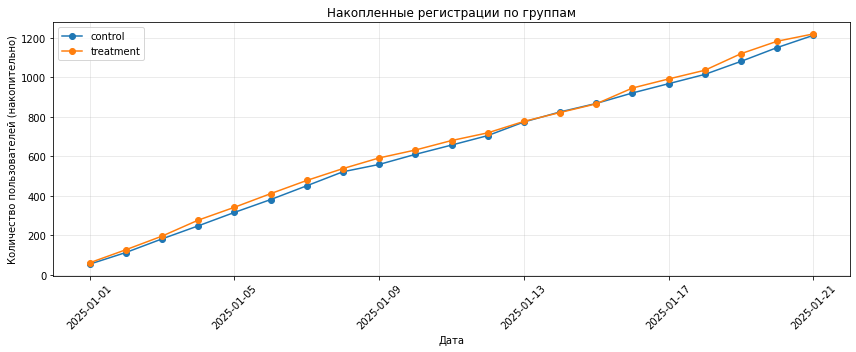

In [158]:
reg_by_day = (
    test_users.groupby([test_users['registration_date'].dt.date, 'group'])['user_id']
    .nunique()
    .reset_index(name='new_users')
)

reg_by_day = reg_by_day.sort_values('registration_date')
reg_by_day['cumulative_users'] = reg_by_day.groupby('group')['new_users'].cumsum()

plt.figure(figsize=(12, 5))
for group_name in ['control', 'treatment']:
    data = reg_by_day[reg_by_day['group'] == group_name]
    plt.plot(data['registration_date'], data['cumulative_users'], marker='o', label=group_name)

plt.title('Накопленные регистрации по группам')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей (накопительно)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [159]:
print('По устройствам:')
print(test_users.groupby(['group', 'device'])['user_id'].nunique().unstack())

print('\nПо регионам:')
print(test_users.groupby(['group', 'region'])['user_id'].nunique().unstack())

По устройствам:
device     desktop  mobile  tablet
group                             
control        396     431     386
treatment      401     371     448

По регионам:
region     Другие регионы  Екатеринбург  Краснодар  Москва  \
group                                                        
control               390            56         52     308   
treatment             415            66         39     299   

region     Московская область  Нижний Новгород  Новосибирск  Ростов-на-Дону  \
group                                                                         
control                    90               51           52              32   
treatment                  97               48           43              33   

region     Санкт-Петербург  
group                       
control                182  
treatment              180  


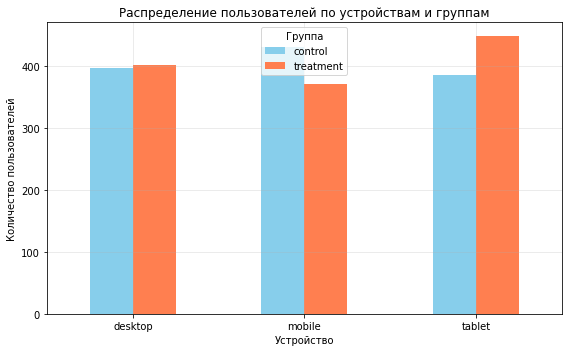

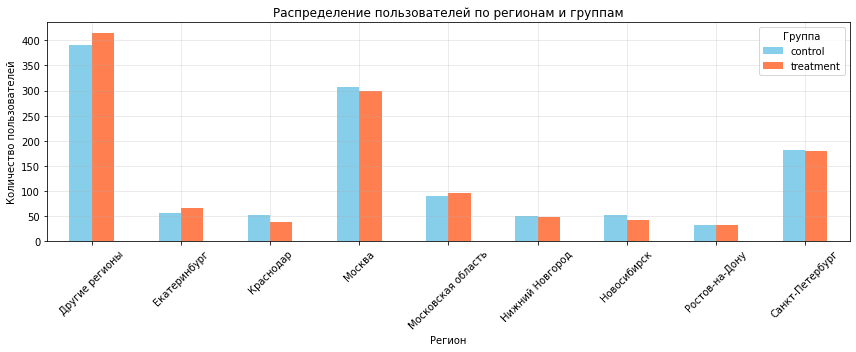

In [160]:
device_dist = test_users.groupby(['group', 'device'])['user_id'].nunique().unstack()

plt.figure(figsize=(8, 5))
device_dist.T.plot(kind='bar', ax=plt.gca(), color=['skyblue', 'coral'])
plt.title('Распределение пользователей по устройствам и группам')
plt.xlabel('Устройство')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=0)
plt.legend(title='Группа')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

region_dist = test_users.groupby(['group', 'region'])['user_id'].nunique().unstack()

plt.figure(figsize=(12, 5))
region_dist.T.plot(kind='bar', ax=plt.gca(), color=['skyblue', 'coral'])
plt.title('Распределение пользователей по регионам и группам')
plt.xlabel('Регион')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.legend(title='Группа',loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Промежуточный вывод по диагностике данных для A/B-теста:

- Датасеты содержат все действия пользователей за период с *1 января 2024 по 26 января 2025*. 
- Явных дубликатов не обнаружено ни в одной таблице.
- Пропуски в `product_name` таблицы events_ab и utm_campaign_id таблицы sessions_ab структурные и не влияют на проведение A/B-теста.
- Все пользователи в `users_ab` привлечены через канал `TikTok`, что соответствует дизайну эксперимента.
- Проверка разделения пользователей показала равномерность: пересечений между группами нет, распределение сбалансированное — *control 1503 (51%), treatment 1465 (49%)*. Период регистрации в обеих группах идет *с 1 по 26 января 2025*.
- Согласно дизайну теста период набора аудитории составляет фиксированные 3 недели, поэтому в дальнейший анализ включены только пользователи, зарегистрированные до 22 января 2025: *control 1213 (50%), treatment 1220 (50%)*. Такое ограничение даёт всем пользователям минимум 5 дней на совершение покупки и делает сравнение корректным с точки зрения вводных данных.
- Анализ активности тестовой аудитории показал, что *80.6%* пользователей вообще не имеют событий или заказов после регистрации, это подтверждает историческое наблюдение о низком качестве TikTok-трафика.
- Визуализация накопленных регистраций подтвердила, что *rolling split* проходит корректно и линии двух групп идут практически параллельно на протяжении всего периода набора.
- Распределение пользователей по устройствам и регионам между группами также сбалансированное, разброс не превышает 5–10% в каждом сегменте, никаких перекосов не наблюдается.

Перед тем, как переходить к расчетам метрик A/B-теста, сформулируем гипотезы, которые необходимо будет проверить статистически:

- Основная метрика — конверсия в первую покупку:
    - H0: конверсия в первую покупку в тестовой и контрольной группах одинаковая
    - H1: конверсии отличаются
- Вспомогательная метрика ARPU:
    - H0: средняя выручка на пользователя в тестовой и контрольной группах одинаковая
    - H1: средние отличаются
- Вспомогательная метрика ARPPU:
    - H0: средняя выручка на платящего пользователя в тестовой и контрольной группах одинаковая
    - H1: средние отличаются
- Вспомогательная метрика AOV:
    - H0: средний чек заказа в тестовой и контрольной группах одинаковый
    - H1: средние чеки отличаются

In [161]:
test_orders['revenue'] = test_orders['total_price'] * 0.05

control_size = len(control_users)
treatment_size = len(treatment_users)

control_buyers = test_orders[test_orders['group'] == 'control']['user_id'].nunique()
treatment_buyers = test_orders[test_orders['group'] == 'treatment']['user_id'].nunique()

control_revenue = test_orders[test_orders['group'] == 'control']['revenue'].sum()
treatment_revenue = test_orders[test_orders['group'] == 'treatment']['revenue'].sum()

metrics_ab = pd.DataFrame({
    'metric': ['CR в первую покупку, %', 'ARPU', 'ARPPU', 'AOV', 'Общая выручка'],
    'control': [
        control_buyers / control_size * 100,
        control_revenue / control_size,
        control_revenue / control_buyers,
        test_orders[test_orders['group'] == 'control']['total_price'].mean(),
        control_revenue
    ],
    'treatment': [
        treatment_buyers / treatment_size * 100,
        treatment_revenue / treatment_size,
        treatment_revenue / treatment_buyers,
        test_orders[test_orders['group'] == 'treatment']['total_price'].mean(),
        treatment_revenue
    ]
})

metrics_ab['absolute_diff'] = (metrics_ab['treatment'] - metrics_ab['control']).round(2)
metrics_ab['relative_diff_%'] = ((metrics_ab['treatment'] - metrics_ab['control']) / metrics_ab['control'] * 100).round(2)
print(metrics_ab.round(2))

                   metric   control  treatment  absolute_diff  relative_diff_%
0  CR в первую покупку, %      1.32       8.93           7.62           577.34
1                    ARPU     15.60     157.25         141.66           908.26
2                   ARPPU   1182.42    1760.09         577.68            48.86
3                     AOV  15765.54   16682.64         917.10             5.82
4           Общая выручка  18918.64  191850.31      172931.66           914.08


In [162]:
z_stat, pvalue_cr = proportions_ztest([treatment_buyers, control_buyers], [treatment_size, control_size])

control_amounts = test_orders[test_orders['group'] == 'control'].groupby('user_id')['revenue'].sum()
treatment_amounts = test_orders[test_orders['group'] == 'treatment'].groupby('user_id')['revenue'].sum()

control_arpu_arr = control_amounts.reindex(list(control_users), fill_value=0)
treatment_arpu_arr = treatment_amounts.reindex(list(treatment_users), fill_value=0)

t_arpu, pvalue_arpu = ttest_ind(treatment_arpu_arr, control_arpu_arr)

t_arppu, pvalue_arppu = ttest_ind(treatment_amounts, control_amounts)

control_prices = test_orders[test_orders['group'] == 'control']['total_price']
treatment_prices = test_orders[test_orders['group'] == 'treatment']['total_price']
t_aov, pvalue_aov = ttest_ind(treatment_prices, control_prices)

print(f'CR: p-value = {pvalue_cr:.4f}')
print(f'ARPU: p-value = {pvalue_arpu:.4f}')
print(f'ARPPU: p-value = {pvalue_arppu:.4f}')
print(f'AOV: p-value = {pvalue_aov:.4f}')

CR: p-value = 0.0000
ARPU: p-value = 0.0000
ARPPU: p-value = 0.3007
AOV: p-value = 0.8467


Проанализируем результаты статистических тестов:
- `CR` в первую покупку: p-value = 0.0000 эффект статистически значим, конверсия выросла с **1.32% до 8.93%**, рост более чем в 6 раз
- `ARPU`: p-value = 0.0000 эффект статистически значим. Средняя выручка на пользователя выросла с 15.6 до 157.25 — почти в 10 раз.
- `ARPPU`: p-value = 0.3007 эффект статистически не значим. Платящие пользователи в тестовой группе тратят больше больше (1760 против 1182), но разница может быть случайной из-за недостаточно большой выборки.
- `AOV`: p-value = 0.8467 эффект статистически не значим. Средний чек в группах практически одинаковый.

Главный эффект от бонуса проявляется в вовлечении пользователей в покупку, а не в увеличении суммы одного заказа, пользователи с бонусом все чаще решаются купить, но выбирают примерно такие же по стоимости товары, как и без бонуса, при этом общая выручка тестовой группы выросла в 10 раз и составила **191 тысяч против 19 тысяч** в контрольной, что значит, что барьерная метрика показала отличные результаты.

In [165]:
device_stats = test_users.merge(
    test_orders[['user_id']].drop_duplicates().assign(has_order=1),
    on='user_id',
    how='left'
)
device_stats['has_order'] = device_stats['has_order'].fillna(0)

device_cr = device_stats.groupby(['device', 'group']).agg(
    users=('user_id', 'nunique'),
    buyers=('has_order', 'sum')
).reset_index()
device_cr['CR_%'] = (device_cr['buyers'] / device_cr['users'] * 100).round(2)
print('CR по устройствам:')
print(device_cr)

region_cr = device_stats.groupby(['region', 'group']).agg(
    users=('user_id', 'nunique'),
    buyers=('has_order', 'sum')
).reset_index()
region_cr['CR_%'] = (region_cr['buyers'] / region_cr['users'] * 100).round(2)
print('CR по регионам:')
print(region_cr)

gender_cr = device_stats.groupby(['gender', 'group']).agg(
    users=('user_id', 'nunique'),
    buyers=('has_order', 'sum')
).reset_index()
gender_cr['CR_%'] = (gender_cr['buyers'] / gender_cr['users'] * 100).round(2)
print('CR по полу:')
print(gender_cr)

os_cr = device_stats.groupby(['os', 'group']).agg(
    users=('user_id', 'nunique'),
    buyers=('has_order', 'sum')
).reset_index()
os_cr['CR_%'] = (os_cr['buyers'] / os_cr['users'] * 100).round(2)
print('CR по ОС:')
print(os_cr)

CR по устройствам:
    device      group  users  buyers   CR_%
0  desktop    control    396     4.0   1.01
1  desktop  treatment    401    35.0   8.73
2   mobile    control    431     5.0   1.16
3   mobile  treatment    371    28.0   7.55
4   tablet    control    386     7.0   1.81
5   tablet  treatment    448    46.0  10.27
CR по регионам:
                region      group  users  buyers   CR_%
0       Другие регионы    control    390     3.0   0.77
1       Другие регионы  treatment    415    34.0   8.19
2         Екатеринбург    control     56     1.0   1.79
3         Екатеринбург  treatment     66     6.0   9.09
4            Краснодар    control     52     2.0   3.85
5            Краснодар  treatment     39     2.0   5.13
6               Москва    control    308     4.0   1.30
7               Москва  treatment    299    31.0  10.37
8   Московская область    control     90     2.0   2.22
9   Московская область  treatment     97    10.0  10.31
10     Нижний Новгород    control     51 

По сегментации все группы демонстрируют примерно одинаковые значения и показывают этим, что введение бонуса универсально и может быть запущено для всей аудитории.

In [163]:
test_users['reg_day'] = test_users['registration_date'].dt.date

records = []

for current_date in sorted(test_users['reg_day'].unique()):
    users_to_date = test_users[test_users['reg_day'] <= current_date]
    
    control_ids = users_to_date[users_to_date['group'] == 'control']['user_id']
    treatment_ids = users_to_date[users_to_date['group'] == 'treatment']['user_id']
    
    orders_to_date = test_orders[test_orders['order_date'].dt.date <= current_date]
    
    control_buyers_d = orders_to_date[orders_to_date['user_id'].isin(control_ids)]['user_id'].nunique()
    treatment_buyers_d = orders_to_date[orders_to_date['user_id'].isin(treatment_ids)]['user_id'].nunique()
    
    cr_c = control_buyers_d / len(control_ids) * 100
    cr_t = treatment_buyers_d / len(treatment_ids) * 100
    
    z, pvlaue = proportions_ztest([treatment_buyers_d, control_buyers_d],
                                 [len(treatment_ids), len(control_ids)])
    
    records.append({
        'date': current_date,
        'control_cr': cr_c,
        'treatment_cr': cr_t,
        'p_value': pvlaue
    })

cr_dynamics = pd.DataFrame(records)
print(cr_dynamics)

          date  control_cr  treatment_cr       p_value
0   2025-01-01    0.000000      3.278689  1.794917e-01
1   2025-01-02    0.884956      2.362205  3.722283e-01
2   2025-01-03    0.549451      2.551020  1.197731e-01
3   2025-01-04    0.806452      2.166065  2.042234e-01
4   2025-01-05    0.632911      2.046784  1.187501e-01
5   2025-01-06    0.524934      1.703163  1.180404e-01
6   2025-01-07    0.443459      2.301255  1.598367e-02
7   2025-01-08    0.574713      2.416357  1.395086e-02
8   2025-01-09    0.715564      2.702703  9.919744e-03
9   2025-01-10    0.655738      3.006329  2.127587e-03
10  2025-01-11    0.761035      3.529412  5.128321e-04
11  2025-01-12    0.709220      4.033380  3.987962e-05
12  2025-01-13    0.645995      4.118404  7.436939e-06
13  2025-01-14    0.727273      4.501217  1.566853e-06
14  2025-01-15    0.691244      4.734411  2.172666e-07
15  2025-01-16    0.868621      5.285412  3.809265e-08
16  2025-01-17    0.826446      5.443548  5.247862e-09
17  2025-0

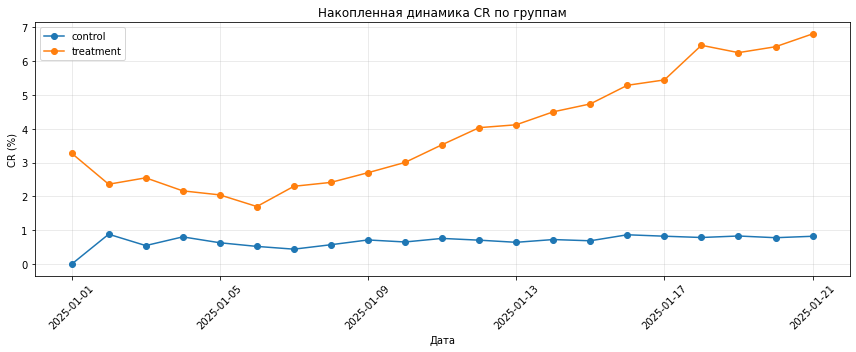

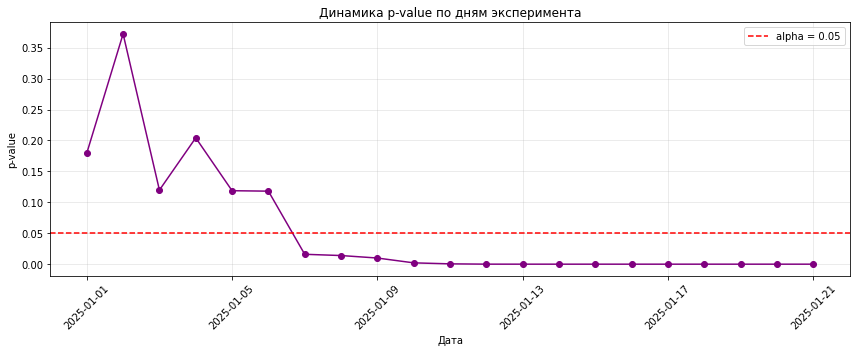

In [164]:
plt.figure(figsize=(12, 5))
plt.plot(cr_dynamics['date'], cr_dynamics['control_cr'], marker='o', label='control')
plt.plot(cr_dynamics['date'], cr_dynamics['treatment_cr'], marker='o', label='treatment')
plt.title('Накопленная динамика CR по группам')
plt.xlabel('Дата')
plt.ylabel('CR (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(cr_dynamics['date'], cr_dynamics['p_value'], marker='o', color='purple')
plt.axhline(y=0.05, linestyle='--', color='red', label='alpha = 0.05')
plt.title('Динамика p-value по дням эксперимента')
plt.xlabel('Дата')
plt.ylabel('p-value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Исходя из графиков видно, что:

Контрольная группа стабильно держалась на уровне **0.7–0.9% CR** весь период, тогда как тестовая выросла с **1.7% до 6.8%**, что говорит о том, что разрыв между группами постоянно увеличивался.
p-value впервые опустился ниже 0.05 на 7 января и с этого момента до конца эксперимента только падал и ложноположительных скачков не было.

## Выводы по этапу 5

**Вывод по этапу 5, в котором проводилось A/B-тестирование бонуса за первую покупку для пользователей канала TikTok:**

Эксперимент проверял гипотезу о том, что бонус на первую покупку повысит конверсию новых пользователей TikTok и результаты смогли подтвердили данную гипотезу с довольно большим запасом, конверсия в первую покупку выросла с **1.32%** в контрольной группе до **8.93%** в тестовой, виден рост в **6.8 раз**, **p-value = 0.0000**, данный результат статистически значимый, от этого и общая выручка тестовой группы выросла аж в **10 раз** до **191 тысяч против 19 тысяч**, барьерная метрика при этом прошла проверку, бонус не только не навредила выручке, но и заметно её увеличил, при этом средний чек одного заказа в группах оказался практически одинаковым и составил **16 682 против 15 765**, **p-value = 0.85**. Это значит, что данный бонус не мотивирует пользователей выбирать более дорогие товары, он дает им стимул совершить первый заказ. Люди с бонусом чаще решаются на покупку, но выбирают такие же по цене товары, как и без него.

Проверка конверсии по сегментам показала, что бонус работает во всех группах пользователей одинаково, и не было обнаружено сегментов где введение вызывало бы отрицательный эффект, поэтому оно универсально.

Динамика проведения теста показала, что эффект стабилен на протяжении всего периода. Контрольная группа держалась без выраженных отклонений на уровне **0.7–0.9% CR**, тогда как тестовая уверенно выросла с **1.7% до 6.8%**, при этом p-value впервые опустился ниже **0.05** на **7-й день** и с этого момента только падал и ложноположительных скачков не было.

**Рекомендации:**

Основной рекомендацией выступает введение бонуса на всю TikTok-аудиторию, так как эффект подтверждён, статистически значим и стабилен для всех. Также стоит рассмотреть возможность применения бонуса на других каналах, где ROI также оставался не самым лучшим. При этом можно отдельно подумать над идеей поднятия среднего чека для аудитории канала TikTok для дополнительного увеличения прибыли.

Также было обнаружено, что даже с бонусом **80%** зарегистрировавшихся так и не заходят в приложение повторно, эта огромная аудитория уходит возможно даже не узнав о новой механике для них, поэтому стоит запустить рассылки и пуш-уведомления сразу после захода в приложение впервые.

**Проблемы эксперимента:**

Основная проблема, которая была указана в условиях, что тест был запущен без предварительного расчёта мощности и MDE из-за срочности задачи. В данном случае это оказалось не критично из-за сильного эффекта акции. Но при более слабом эффекте тест мог бы дать неверный результат из-за маленькой выборки или незафиксированного положительного эффекта, поэтому при следующих экспериментах стоит закладывать время на расчёт мощности и MDE.

Вторая проблема — это то, что **80.6%** тестовых пользователей вообще не проявили никакой активности после регистрации. Это значит, что эксперимент оценивал показатели лишь **20%** активной аудитории, а причины такой низкой активности могут быть разные — например, пользователь увидел бонус, но не заинтересовался, или же вообще не зашёл в приложение после регистрации и о бонусе не узнал. Это показывает, что большая аудитория, пришедшая с TikTok, просто может быть не самой заинтересованной в продукте.

Третья проблема заключается в том, что при используемом варианте набора пользователей `rolling split` получилось так, что у пользователей было разное время для взаимодействия с продуктом — те, кто зарегистрировался в первые дни теста, имели до **3 недель** на совершение покупки, а те, кто зарегистрировался в последние дни — всего **5 дней**. Поэтому было бы лучше сделать оценку с фиксированным количеством дней наблюдения для каждого пользователя, например неделю.

И четвёртая проблема — это то, что контрольная группа получилась очень маленькой по количеству заказов, всего **16 покупателей и 24 заказа**, и из-за такого малого числа заказов один случайный клиент с крупным чеком мог сильно повлиять на агрегированные метрики вроде ARPPU и AOV, поэтому эти показатели достаточно нестабильные при такой выборке и по ним не совсем корректно делать надёжные выводы.